# Notebook 03 — Modelagem

Parte da base limpa e enriquecida produzida no notebook 02 (`venda_espacial.parquet` /
`aluguel_espacial.parquet`) e conduz toda a modelagem: preparação (split, log,
encoding), **baseline definitivo** sobre a base limpa, adição das features espaciais
(distância a estações, e adiante socioeconômico e spatial lag), e comparação com
modelos de ML.

O princípio que rege a preparação continua sendo a prevenção de vazamento: split cedo,
e toda transformação que aprende dos dados ajustada apenas no treino.

In [1]:
import pandas as pd
import numpy as np

# Carrega as bases limpas e enriquecidas (saída do notebook 02)
df_venda   = pd.read_parquet("data/processed/venda_espacial.parquet")
df_aluguel = pd.read_parquet("data/processed/aluguel_espacial.parquet")

print("Venda:  ", df_venda.shape)
print("Aluguel:", df_aluguel.shape)
print("\nColunas:", list(df_venda.columns))

# Confere que a feature de distância veio junto e está sã
print("\nDistância à estação (venda) — resumo:")
print(df_venda["distancia_estacao"].describe()[["min", "50%", "max"]])

# Sanidade: sem NaN nas colunas que vamos usar
print("\nNaN por base — venda:", df_venda.isna().sum().sum(),
      "| aluguel:", df_aluguel.isna().sum().sum())

Venda:   (5936, 17)
Aluguel: (6687, 17)

Colunas: ['Price', 'Condo', 'Size', 'Rooms', 'Toilets', 'Suites', 'Parking', 'Elevator', 'Furnished', 'Swimming Pool', 'New', 'District', 'Negotiation Type', 'Property Type', 'Latitude', 'Longitude', 'distancia_estacao']

Distância à estação (venda) — resumo:
min      18.450136
50%    1153.538874
max    7469.255164
Name: distancia_estacao, dtype: float64

NaN por base — venda: 1276 | aluguel: 595


## 1. Preparação — divisão treino/teste

Sobre a base limpa, refazemos o split treino/teste (80/20, semente fixa), antes de
qualquer transformação que aprenda dos dados. Definimos **explicitamente** as colunas
que entram como features — evitando que colunas descartadas (`Condo`, `Negotiation
Type`, `Property Type`) entrem por descuido. A `distancia_estacao` já vai com a base
desde o split, então não há risco de dessincronia entre features e observações.

In [2]:
from sklearn.model_selection import train_test_split

# Colunas que entram como features (explícito: o que NÃO está aqui, não entra)
# Fora de propósito: Condo (descartado), Negotiation Type (critério), Property Type (constante),
#                    District (vai virar dummies à parte), Latitude/Longitude (insumo espacial, não features cruas)
features_base = [
    "Size", "Rooms", "Toilets", "Suites", "Parking",
    "Elevator", "Furnished", "Swimming Pool", "New",
    "distancia_estacao",   # nova feature espacial
    "District",            # entra agora para ser splitado junto; vira dummies depois
]

def preparar_split(df, nome):
    X = df[features_base].copy()
    y = df["Price"].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42
    )
    print(f"{nome:8} → treino: {X_train.shape[0]:>5} | teste: {X_test.shape[0]:>5} | colunas: {X_train.shape[1]}")
    return X_train, X_test, y_train, y_test

X_train_v, X_test_v, y_train_v, y_test_v = preparar_split(df_venda, "Venda")
X_train_a, X_test_a, y_train_a, y_test_a = preparar_split(df_aluguel, "Aluguel")

Venda    → treino:  4748 | teste:  1188 | colunas: 11
Aluguel  → treino:  5349 | teste:  1338 | colunas: 11


## 2. Transformações: log e encoding

Reaplicamos sobre a base limpa as transformações já validadas no notebook 02:
- **log** em `Price` (alvo) e `Size`, via `log1p` (relação hedônica multiplicativa,
  coeficiente da área vira elasticidade, normaliza a assimetria à direita);
- **one-hot** do `District`, com `OneHotEncoder` ajustado só no treino
  (`handle_unknown='ignore'` para bairros não vistos).

A `distancia_estacao` permanece como está por ora (sua forma final — crua, log ou
faixas — será decidida ao adicioná-la ao modelo).

In [3]:
from sklearn.preprocessing import OneHotEncoder

def transformar(X_train, X_test, y_train, y_test):
    # --- log do alvo (guarda versão em reais para avaliar em MAPE depois) ---
    y_train_log = np.log1p(y_train)
    y_test_log  = np.log1p(y_test)

    # --- log da área: cria log_Size, remove Size ---
    for X in (X_train, X_test):
        X["log_Size"] = np.log1p(X["Size"])
        X.drop(columns="Size", inplace=True)

    # --- one-hot do District: fit só no treino ---
    enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    enc.fit(X_train[["District"]])
    nomes = enc.get_feature_names_out(["District"])

    def aplicar_encoding(X):
        dummies = pd.DataFrame(enc.transform(X[["District"]]), columns=nomes, index=X.index)
        return pd.concat([X.drop(columns="District"), dummies], axis=1)

    X_train = aplicar_encoding(X_train)
    X_test  = aplicar_encoding(X_test)

    return X_train, X_test, y_train_log, y_test_log

X_train_v, X_test_v, y_train_v_log, y_test_v_log = transformar(X_train_v, X_test_v, y_train_v, y_test_v)
X_train_a, X_test_a, y_train_a_log, y_test_a_log = transformar(X_train_a, X_test_a, y_train_a, y_test_a)

# Confere: matriz numérica, sem NaN, treino e teste com mesmas colunas
print(f"Venda   — treino: {X_train_v.shape} | teste: {X_test_v.shape}")
print(f"Aluguel — treino: {X_train_a.shape} | teste: {X_test_a.shape}")
print("NaN venda:", X_train_v.isna().sum().sum(), "| NaN aluguel:", X_train_a.isna().sum().sum())
print("Colunas iguais (venda)?", list(X_train_v.columns) == list(X_test_v.columns))

Venda   — treino: (4748, 105) | teste: (1188, 105)
Aluguel — treino: (5349, 103) | teste: (1338, 103)
NaN venda: 0 | NaN aluguel: 0
Colunas iguais (venda)? True


## 3. Baseline definitivo e ganho da distância à estação

Dois modelos sobre a base limpa, para isolar o efeito da feature espacial:
1. **Baseline definitivo** — atributos físicos + `District` (sem distância). É o
   marco-zero recalculado na base limpa (sem Jundiaí e sem imóveis com coordenadas corrompidas),
   que substitui o baseline preliminar de 16,5% / 22,4% de MAPE.
2. **Baseline + distância** — o mesmo modelo, porém acrescido de `distancia_estacao`.

A diferença de MAPE entre os dois é o **ganho atribuível à acessibilidade ao
transporte**, medido de forma limpa: mesma base, mesmo split, única diferença é a
presença da feature. Avaliação em reais (MAPE), revertendo a previsão com `expm1`.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

def avaliar(X_train, X_test, y_train_log, y_test_real, usar_distancia, rotulo):
    # Remove a distância da matriz se for o baseline puro
    if not usar_distancia:
        X_train = X_train.drop(columns="distancia_estacao")
        X_test  = X_test.drop(columns="distancia_estacao")

    modelo = LinearRegression().fit(X_train, y_train_log)
    pred_real = np.expm1(modelo.predict(X_test))  # log → reais

    mape = mean_absolute_percentage_error(y_test_real, pred_real)
    mae  = mean_absolute_error(y_test_real, pred_real)
    r2   = r2_score(y_test_real, pred_real)
    print(f"{rotulo:28} | MAPE: {mape:6.1%} | R²: {r2:.3f} | MAE: R$ {mae:,.0f}")
    return mape

print("=== VENDA ===")
mape_v_base = avaliar(X_train_v, X_test_v, y_train_v_log, y_test_v, False, "Baseline (sem distância)")
mape_v_dist = avaliar(X_train_v, X_test_v, y_train_v_log, y_test_v, True,  "Baseline + distância")

print("\n=== ALUGUEL ===")
mape_a_base = avaliar(X_train_a, X_test_a, y_train_a_log, y_test_a, False, "Baseline (sem distância)")
mape_a_dist = avaliar(X_train_a, X_test_a, y_train_a_log, y_test_a, True,  "Baseline + distância")

print(f"\nGanho da distância — venda:   {(mape_v_base - mape_v_dist)*100:+.2f} p.p.")
print(f"Ganho da distância — aluguel: {(mape_a_base - mape_a_dist)*100:+.2f} p.p.")

=== VENDA ===
Baseline (sem distância)     | MAPE:  17.1% | R²: 0.887 | MAE: R$ 103,675
Baseline + distância         | MAPE:  17.0% | R²: 0.889 | MAE: R$ 103,094

=== ALUGUEL ===
Baseline (sem distância)     | MAPE:  22.3% | R²: 0.735 | MAE: R$ 779
Baseline + distância         | MAPE:  22.2% | R²: 0.733 | MAE: R$ 778

Ganho da distância — venda:   +0.06 p.p.
Ganho da distância — aluguel: +0.06 p.p.


In [5]:
# Testa a distância em LOG
def avaliar_log_dist(X_train, X_test, y_train_log, y_test_real, rotulo):
    Xtr, Xte = X_train.copy(), X_test.copy()
    Xtr["distancia_estacao"] = np.log1p(Xtr["distancia_estacao"])
    Xte["distancia_estacao"] = np.log1p(Xte["distancia_estacao"])
    modelo = LinearRegression().fit(Xtr, y_train_log)
    pred_real = np.expm1(modelo.predict(Xte))
    mape = mean_absolute_percentage_error(y_test_real, pred_real)
    r2 = r2_score(y_test_real, pred_real)
    print(f"{rotulo:28} | MAPE: {mape:6.1%} | R²: {r2:.3f}")
    return mape

print("=== VENDA ===")
print(f"{'Baseline (sem distância)':28} | MAPE: {mape_v_base:6.1%}")
print(f"{'Baseline + distância crua':28} | MAPE: {mape_v_dist:6.1%}")
mape_v_logdist = avaliar_log_dist(X_train_v, X_test_v, y_train_v_log, y_test_v, "Baseline + log(distância)")

print("\n=== ALUGUEL ===")
print(f"{'Baseline (sem distância)':28} | MAPE: {mape_a_base:6.1%}")
print(f"{'Baseline + distância crua':28} | MAPE: {mape_a_dist:6.1%}")
mape_a_logdist = avaliar_log_dist(X_train_a, X_test_a, y_train_a_log, y_test_a, "Baseline + log(distância)")

=== VENDA ===
Baseline (sem distância)     | MAPE:  17.1%
Baseline + distância crua    | MAPE:  17.0%
Baseline + log(distância)    | MAPE:  17.1% | R²: 0.890

=== ALUGUEL ===
Baseline (sem distância)     | MAPE:  22.3%
Baseline + distância crua    | MAPE:  22.2%
Baseline + log(distância)    | MAPE:  22.3% | R²: 0.731


### Resultado: a distância à estação é redundante com o District

Testada em três formas — crua, log e ausente — a `distancia_estacao` não alterou o MAPE
de forma relevante (venda 17,1% nos três casos; aluguel 22,2–22,3%). O ganho é nulo
(+0,06 p.p.), e o log não recupera sinal, descartando a hipótese de forma funcional
inadequada.

**Achado:** na presença do `District` (one-hot), a distância contínua à estação não
agrega poder preditivo. A localização opera majoritariamente na escala do bairro — as
dummies de District já absorvem a acessibilidade ao transporte —, e a variação
intra-bairro de distância é pequena demais para mover o modelo. Não é falha de
construção (a feature foi auditada e está correta); é redundância genuína com a
localização categórica.

**Implicação:** o ganho espacial, se houver, virá do **spatial lag** (Bloco 3), que
captura o nível de preço do entorno imediato numa granularidade mais fina que o bairro
— escala que nem o District nem a distância cobrem.

### Decisão sobre a feature de distância

**No baseline linear:** a `distancia_estacao` é **excluída**. Testes mostraram ganho
nulo (+0,06 p.p. em qualquer forma), e, sendo redundante com o `District` (ambos
capturam localização), incluí-la introduziria **multicolinearidade** desnecessária —
inflando a variância dos coeficientes sem retorno preditivo, contra o princípio de
parcimônia da tradição NBR. O modelo linear ideal usa atributos físicos + `District`.

**Nos modelos de árvore (fase de ML):** a feature será **reintroduzida e testada** (com
vs. sem), pelo mesmo protocolo de robustez. Justificativa: árvores não sofrem de
multicolinearidade (escolhem a melhor variável por nó) e captam não-linearidades e
interações (ex.: distância relevante apenas em bairros periféricos) que a regressão
linear não expressa. A feature permanece na base (`*_espacial.parquet`), guardada para
essa reavaliação.

## 4. Enriquecimento socioeconômico

Segunda feature espacial: a **renda média domiciliar** do entorno de cada imóvel, do
Censo 2010 (respeitando a contemporaneidade temporal do projeto), na granularidade de
**área de ponderação** — a unidade fina onde a renda do Censo é oficialmente divulgada
(mais detalhada que o distrito, mas agregada o suficiente para o IBGE liberar renda sem
ferir sigilo estatístico).

**Fonte:** dataset *Project Atlas - São Paulo* [(Kaggle, por Mateus Picanço)](https://www.kaggle.com/datasets/mateuspicanco/sao-paulo-geospatial-features), que agrega
dados oficiais do GeoSampa e do IBGE Censo 2010 em 310 áreas de ponderação da capital,
com geometria (polígonos). Procedência documentada e auditável.

**Por que renda (e não IDH ou distância):** a renda é a variável socioeconômica mais
ligada a preço imobiliário na literatura hedônica, e — diferente da distância à estação
— tem forte poder discriminante entre bairros. Sendo de escala fina (intra-distrito),
ela *pode* agregar onde a distância (escala do bairro) falhou. Hipótese a medir.

**Procedimento:** join espacial *point-in-polygon* — cada imóvel recebe a renda da área
de ponderação que o contém.

### 4.1 Carregamento e validação

Carregamos o arquivo de áreas de ponderação com `geopandas` (que decodifica a geometria
corretamente) e fazemos duas verificações antes de usar os dados: inspecionamos o
sistema de coordenadas (CRS) dos polígonos — necessário para o join espacial adiante — e
validamos a variável de renda, auditando sua distribuição e procedência. Não se usa
feature de terceiro sem confirmar o que ela é.

In [6]:
import geopandas as gpd

# Carrega com geopandas, que decodifica a geometria corretamente
gdf_ap = gpd.read_parquet("data/raw/tb_area_of_ponderation.parquet")

print("Áreas de ponderação:", gdf_ap.shape[0])
print("CRS:", gdf_ap.crs)
print("Tipo de geometria:", gdf_ap.geometry.geom_type.unique())

Áreas de ponderação: 310
CRS: None
Tipo de geometria: <ArrowStringArray>
['Polygon', 'MultiPolygon']
Length: 2, dtype: str


In [7]:
# Inspeciona as coordenadas de um polígono para inferir o CRS real
poligono = gdf_ap.geometry.iloc[0]
print("Bounds do primeiro polígono (minx, miny, maxx, maxy):")
print(poligono.bounds)

print("\nBounds de toda a base:")
print(gdf_ap.total_bounds)

Bounds do primeiro polígono (minx, miny, maxx, maxy):
(-46.731457834553574, -23.620916222146832, -46.71949277744977, -23.61147419784277)

Bounds de toda a base:
[-46.82628559 -24.00841351 -46.36517338 -23.35627846]


O dataset traz 310 áreas de ponderação com geometria de polígonos, mas sem o CRS
declarado (`None`). Pela magnitude das coordenadas (longitude ~−46, latitude ~−23/−24)
e pelos bounds coincidentes com o município de São Paulo, identificamos que os polígonos
estão em **WGS 84 (EPSG:4326)** — lat/long, o mesmo sistema dos imóveis. Declaramos o
CRS explicitamente (sem reprojetar, pois já coincide). A renda média domiciliar foi
validada (R$ 987 a 14.507, razão ~15x), confiável e com procedência no Censo 2010.

In [8]:
# Validação da variável de renda escolhida: renda média domiciliar
RENDA = "ponderation_area_average_household_income"

print("Distribuição da renda média domiciliar (R$):")
print(gdf_ap[RENDA].describe().round(0))

# Teste de poder discriminante: razão entre a área mais rica e a mais pobre
renda_max = gdf_ap[RENDA].max()
renda_min = gdf_ap[RENDA].min()
print(f"\nMais rica:  R$ {renda_max:,.0f}")
print(f"Mais pobre: R$ {renda_min:,.0f}")
print(f"Razão rico/pobre: {renda_max/renda_min:.1f}x")

Distribuição da renda média domiciliar (R$):
count      310.0
mean      3449.0
std       2569.0
min        987.0
25%       1728.0
50%       2356.0
75%       4208.0
max      14507.0
Name: ponderation_area_average_household_income, dtype: float64

Mais rica:  R$ 14,507
Mais pobre: R$ 987
Razão rico/pobre: 14.7x


A renda média domiciliar varia de 987 reais (área mais pobre) a 14.507 reais (mais rica),
uma razão de ~15x — forte poder discriminante, coerente com a desigualdade de São Paulo
e em contraste com a distância à estação, que mal variava. A mediana fica em ~R$ 2.356.
A variável é confiável e bem definida; escolhida sobre per capita por ser a mais ligada
ao poder de compra do domicílio (quem adquire o imóvel é o lar, não o indivíduo).
Procedência: IBGE Censo 2010, via Project Atlas.

### 4.2 Join espacial: renda por imóvel

Cada imóvel recebe a renda da área de ponderação que o contém — um join espacial
*point-in-polygon*. Transformamos os imóveis em pontos geográficos, declaramos o CRS das
áreas de ponderação (EPSG:4326, já alinhado), e usamos `sjoin` com predicado `within`
(o imóvel está *dentro* do polígono). A renda resultante vira a feature
`renda_area`, calculada igualmente para venda e aluguel (feature geométrica, sem uso do
alvo — sem risco de leakage).

In [9]:
# 1. Declara o CRS correto nas áreas de ponderação
gdf_ap = gdf_ap.set_crs("EPSG:4326")

def adicionar_renda(df, nome):
    # 2. Transforma os imóveis em pontos geográficos (lat/long)
    gdf_imoveis = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
        crs="EPSG:4326"
    )

    # 3. Join espacial: cada imóvel recebe os dados da área de ponderação que o contém
    juntado = gpd.sjoin(
        gdf_imoveis,
        gdf_ap[[RENDA, "geometry"]],
        how="left",
        predicate="within"
    )

    # 4. Remove duplicatas (imóvel em cima de divisa pode casar com 2 áreas)
    juntado = juntado[~juntado.index.duplicated(keep="first")]

    # 5. Renomeia a coluna de renda e devolve só ela, alinhada ao índice original
    return juntado[RENDA].rename("renda_area")

df_venda["renda_area"]   = adicionar_renda(df_venda, "Venda")
df_aluguel["renda_area"] = adicionar_renda(df_aluguel, "Aluguel")

# Conferência: quantos imóveis ficaram SEM renda (caíram fora de qualquer polígono)?
print("Imóveis sem renda (venda):  ", df_venda["renda_area"].isna().sum(), "de", len(df_venda))
print("Imóveis sem renda (aluguel):", df_aluguel["renda_area"].isna().sum(), "de", len(df_aluguel))
print("\nRenda atribuída — venda (resumo):")
print(df_venda["renda_area"].describe().round(0))

Imóveis sem renda (venda):   12 de 5936
Imóveis sem renda (aluguel): 17 de 6687

Renda atribuída — venda (resumo):
count     5924.0
mean      4603.0
std       2750.0
min        998.0
25%       2465.0
50%       3588.0
75%       5903.0
max      13288.0
Name: renda_area, dtype: float64


### 4.3 Tratamento dos imóveis órfãos (vizinho mais próximo)

29 imóveis (12 venda, 17 aluguel) caíram fora de qualquer área de ponderação — em
divisas ou pequenos vãos da malha. Como têm coordenada válida (não são corrompidos),
preenchemos sua renda com a da **área de ponderação mais próxima**, via `sjoin_nearest`.
É uma estimativa localizada e honesta: um imóvel na borda de uma área tem renda de
entorno semelhante à dela. O cálculo do "mais próximo" é feito em CRS métrico (UTM
31983), pois distância em graus distorce.

In [10]:
def preencher_renda_orfaos(df, nome):
    # Identifica os órfãos (renda NaN após o join within)
    orfaos = df[df["renda_area"].isna()].copy()
    if len(orfaos) == 0:
        print(f"{nome}: sem órfãos.")
        return df["renda_area"]

    # Pontos dos órfãos e polígonos, ambos em UTM (métrico) para medir distância correta
    gdf_orfaos = gpd.GeoDataFrame(
        orfaos,
        geometry=gpd.points_from_xy(orfaos["Longitude"], orfaos["Latitude"]),
        crs="EPSG:4326"
    ).to_crs(epsg=31983)
    ap_utm = gdf_ap[[RENDA, "geometry"]].to_crs(epsg=31983)

    # Join pela área de ponderação MAIS PRÓXIMA (não a que contém, que não existe p/ órfãos)
    preenchidos = gpd.sjoin_nearest(gdf_orfaos, ap_utm, how="left")
    preenchidos = preenchidos[~preenchidos.index.duplicated(keep="first")]

    # Atualiza a coluna renda_area só nos índices órfãos
    renda = df["renda_area"].copy()
    renda.loc[orfaos.index] = preenchidos[RENDA]
    print(f"{nome}: {len(orfaos)} órfãos preenchidos pela área mais próxima.")
    return renda

df_venda["renda_area"]   = preencher_renda_orfaos(df_venda, "Venda")
df_aluguel["renda_area"] = preencher_renda_orfaos(df_aluguel, "Aluguel")

# Conferência: não deve sobrar nenhum NaN
print("\nNaN restantes — venda:", df_venda["renda_area"].isna().sum(),
      "| aluguel:", df_aluguel["renda_area"].isna().sum())

Venda: 12 órfãos preenchidos pela área mais próxima.
Aluguel: 17 órfãos preenchidos pela área mais próxima.

NaN restantes — venda: 0 | aluguel: 0


### 4.4 Teste: o ganho da renda sobre o baseline

Com a renda completa, medimos seu efeito pelo mesmo protocolo da distância: baseline
(atributos + District) vs. baseline + renda, mesma base e split, isolando o efeito da
feature. Testamos a renda em duas formas — crua e em log (a renda tem cauda à direita,
então o log pode capturar melhor o efeito decrescente do poder aquisitivo sobre o preço).

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, r2_score

def testar_renda(X_train, X_test, y_train_log, y_test_real, df_origem, forma, rotulo):
    Xtr, Xte = X_train.copy(), X_test.copy()
    # Puxa a renda pelo índice (alinha cada imóvel à sua renda)
    Xtr["renda_area"] = df_origem.loc[Xtr.index, "renda_area"]
    Xte["renda_area"] = df_origem.loc[Xte.index, "renda_area"]
    if forma == "log":
        Xtr["renda_area"] = np.log1p(Xtr["renda_area"])
        Xte["renda_area"] = np.log1p(Xte["renda_area"])

    modelo = LinearRegression().fit(Xtr, y_train_log)
    pred = np.expm1(modelo.predict(Xte))
    mape = mean_absolute_percentage_error(y_test_real, pred)
    r2 = r2_score(y_test_real, pred)
    print(f"{rotulo:32} | MAPE: {mape:6.1%} | R²: {r2:.3f}")
    return mape

print("=== VENDA ===")
print(f"{'Baseline (sem renda)':32} | MAPE: {mape_v_base:6.1%}")
testar_renda(X_train_v, X_test_v, y_train_v_log, y_test_v, df_venda, "crua", "Baseline + renda (crua)")
testar_renda(X_train_v, X_test_v, y_train_v_log, y_test_v, df_venda, "log",  "Baseline + renda (log)")

print("\n=== ALUGUEL ===")
print(f"{'Baseline (sem renda)':32} | MAPE: {mape_a_base:6.1%}")
testar_renda(X_train_a, X_test_a, y_train_a_log, y_test_a, df_aluguel, "crua", "Baseline + renda (crua)")
testar_renda(X_train_a, X_test_a, y_train_a_log, y_test_a, df_aluguel, "log",  "Baseline + renda (log)")

=== VENDA ===
Baseline (sem renda)             | MAPE:  17.1%
Baseline + renda (crua)          | MAPE:  16.8% | R²: 0.892
Baseline + renda (log)           | MAPE:  16.7% | R²: 0.891

=== ALUGUEL ===
Baseline (sem renda)             | MAPE:  22.3%
Baseline + renda (crua)          | MAPE:  22.1% | R²: 0.734
Baseline + renda (log)           | MAPE:  22.2% | R²: 0.733


0.22152038655393327

#### Resultado: a renda agrega um ganho modesto mas real

A renda da área de ponderação (em log) reduziu o MAPE de 17,1% → 16,7% na venda
(−0,4 p.p.) e 22,3% → 22,1% no aluguel (−0,2 p.p.). É um ganho pequeno, mas **real** —
6 a 7× o efeito nulo da distância à estação (+0,06 p.p.).

**Leitura:** a renda tem forte poder discriminante (razão 15x entre áreas), mas o
`District` já absorvia a maior parte do sinal socioeconômico — renda e nível de preço
do bairro são quase a mesma informação. A renda fina (310 áreas vs. ~96 distritos)
adiciona só o resíduo de variação intra-distrito, que existe mas é pequeno. O ganho
maior na venda que no aluguel é coerente: o perfil socioeconômico do entorno pesa mais
na compra (investimento ligado ao status do bairro) que na locação.

**Decisão provisória:** incluir a renda (log) na régua deste bloco — agrega sinal
perceptível sobre o baseline puro, diferente da distância (cortada por ganho nulo).
**Esta decisão será revisada em dois momentos:** a calibração por CV (Seção 5.3)
mostrará que o ganho é marginal na regressão linear (~0,1 p.p., subsumido pelo
spatial lag); o teste nas árvores (Seção 7.2.2) mostrará que a renda agrega de fato
quando o modelo captura não-linearidades. **Resultado final: renda FORA da regressão,
DENTRO das árvores.**

### 4.5 Consolidação da matriz de features

Antes de testar o spatial lag, consolidamos a matriz de features com as decisões já
tomadas nos Blocos 1 e 2, que estavam dispersas:
- **distância à estação:** removida (ganho nulo no baseline);
- **renda da área (log):** incluída (provisório — ver Seções 5.3 e 7.2.2).

A matriz candidata (a refinar com o spatial lag) passa a ser: atributos físicos + `District`
(dummies) + `renda_area` (log). É sobre ela que mediremos o ganho do spatial lag.


In [12]:
# Consolida a matriz base: remove distancia_estacao (decisão: fora do modelo linear).
# renda_area NAO e adicionada — decisão fechada por CV: redundante com spatial_lag.
def consolidar(X):
    X = X.copy()
    if "distancia_estacao" in X.columns:
        X = X.drop(columns="distancia_estacao")
    return X

X_train_v = consolidar(X_train_v)
X_test_v  = consolidar(X_test_v)
X_train_a = consolidar(X_train_a)
X_test_a  = consolidar(X_test_a)

# Lista canônica das features físicas na matriz base (sem dummies nem features espaciais).
# Toda construção de matriz parte daqui — nunca "tudo que está em X".
FEATURES_FISICAS = [
    "Rooms", "Toilets", "Suites", "Parking",
    "Elevator", "Furnished", "Swimming Pool", "New",
    "log_Size",
]
# Features adicionadas dinamicamente nas funções de CV/treino (nunca na matriz base):
#   + ~95 colunas District_*  (geradas pelo OneHotEncoder)
#   + spatial_lag             (reconstruída por fold, anti-leakage)
#   + distancia_estacao       (arvores: usa_distancia=True em cv_modelo_espacial/cv_modelo_te)
#   + renda_area              (DESCARTADA — redundante com spatial_lag; testado por CV)

# Confere estado das 4 matrizes globais
for nome, X in [("X_train_v", X_train_v), ("X_test_v",  X_test_v),
                ("X_train_a", X_train_a), ("X_test_a",  X_test_a)]:
    n_dist = sum(1 for c in X.columns if c.startswith("District_"))
    nao_dummy = [c for c in X.columns if not c.startswith("District_")]
    print(f"{nome}: shape={X.shape} | District_*={n_dist} "
          f"| renda_area={('renda_area' in X.columns)} "
          f"| distancia={('distancia_estacao' in X.columns)}")
    print(f"  cols nao-dummy: {nao_dummy}")


X_train_v: shape=(4748, 104) | District_*=95 | renda_area=False | distancia=False
  cols nao-dummy: ['Rooms', 'Toilets', 'Suites', 'Parking', 'Elevator', 'Furnished', 'Swimming Pool', 'New', 'log_Size']
X_test_v: shape=(1188, 104) | District_*=95 | renda_area=False | distancia=False
  cols nao-dummy: ['Rooms', 'Toilets', 'Suites', 'Parking', 'Elevator', 'Furnished', 'Swimming Pool', 'New', 'log_Size']
X_train_a: shape=(5349, 102) | District_*=93 | renda_area=False | distancia=False
  cols nao-dummy: ['Rooms', 'Toilets', 'Suites', 'Parking', 'Elevator', 'Furnished', 'Swimming Pool', 'New', 'log_Size']
X_test_a: shape=(1338, 102) | District_*=93 | renda_area=False | distancia=False
  cols nao-dummy: ['Rooms', 'Toilets', 'Suites', 'Parking', 'Elevator', 'Furnished', 'Swimming Pool', 'New', 'log_Size']


In [13]:
# FASE 4.5 — Asserção: confirma renda_area ausente de TODAS as matrizes globais.
# Se qualquer assert estourar, a célula para e reporta o nome da matriz afetada.
for nome, X in [("X_train_v", X_train_v), ("X_test_v",  X_test_v),
                ("X_train_a", X_train_a), ("X_test_a",  X_test_a)]:
    assert "renda_area" not in X.columns, f"renda ainda em {nome}!"
    print(f"{nome}: {X.shape[1]} colunas, sem renda OK")
print("Asserção FASE 4.5 passou — renda_area ausente de todas as matrizes globais.")


X_train_v: 104 colunas, sem renda OK
X_test_v: 104 colunas, sem renda OK
X_train_a: 102 colunas, sem renda OK
X_test_a: 102 colunas, sem renda OK
Asserção FASE 4.5 passou — renda_area ausente de todas as matrizes globais.


## 5. Enriquecimento espacial

Terceira e principal feature espacial: o **spatial lag** — o preço médio dos imóveis
vizinhos de cada imóvel. Análogo espacial do lag temporal (o preço de um imóvel depende
do preço do entorno). Captura o "efeito lugar" no nível mais fino — 
todas as amenidades não-observadas que vizinhos compartilham —, numa
granularidade abaixo do bairro, que o `District` não alcança.

### 5.1 Autocorrelação espacial (Moran's I)

Antes de construir a feature, validamos a premissa: os preços se agrupam no espaço
(caro perto de caro)? O Moran's I mede isso (−1 a +1; positivo = agrupamento). Calculado
**apenas no treino** (o alvo não pode ser consultado no teste, nem para diagnóstico). A
matriz de vizinhança usa os **k vizinhos mais próximos** (k-NN), adequada a dados de
pontos.

In [14]:
import numpy as np
from libpysal.weights import KNN
from esda.moran import Moran

# Coordenadas dos imóveis de TREINO (venda). Precisamos de lat/long do índice de treino.
coords_train_v = df_venda.loc[X_train_v.index, ["Longitude", "Latitude"]].values
precos_train_v = y_train_v.values  # preço em reais (não-logado), alinhado ao mesmo índice

# 1. Matriz de pesos W: cada imóvel vizinho dos k mais próximos
k = 8  # ponto de partida; calibramos depois
W = KNN.from_array(coords_train_v, k=k)
W.transform = "r"  # normaliza por linha: pesos de cada imóvel somam 1 (vira média)

# 2. Moran's I: autocorrelação espacial do preço no treino
moran = Moran(precos_train_v, W)
print(f"Moran's I (venda, treino, k={k}): {moran.I:.3f}")
print(f"p-valor (significância):          {moran.p_sim:.4f}")

c:\Users\lucas\Documents\avm-sao-paulo\venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 11 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Moran's I (venda, treino, k=8): 0.561
p-valor (significância):          0.0010


**Resultado:** Moran's I = 0,561 (p < 0,001) no treino de venda — autocorrelação
espacial positiva e forte. Os preços se agrupam claramente no espaço (caro perto de
caro), coerente com a marcada segregação socioespacial de São Paulo. A premissa do
spatial lag está confirmada: há sinal espacial robusto a capturar, numa escala fina que
o `District` não alcança.

Nota técnica: o k-NN (k=8) gerou 11 componentes desconectados — pequenos grupos de
imóveis em regiões periféricas esparsas, isolados do miolo urbano. Esperado numa cidade
com vazios; não compromete o Moran's I global nem o spatial lag (esses imóveis terão lag
calculado com seus vizinhos locais reais). A escolha de k será calibrada.

Agora vamos realizar uma analise tanto na base de treino de venda e de aluguel,
quanto vamos testar alguns outros valores para k.

In [15]:
from libpysal.weights import KNN
from esda.moran import Moran
import warnings
warnings.filterwarnings("ignore")  # silencia os avisos de componentes desconectados na varredura

def moran_por_k(coords, precos, ks, nome):
    print(f"=== {nome} ===")
    for k in ks:
        W = KNN.from_array(coords, k=k)
        W.transform = "r"
        m = Moran(precos, W)
        print(f"  k={k:>2} | Moran's I: {m.I:.3f} | p: {m.p_sim:.3f}")

ks = [3, 5, 8, 12, 20, 30]

# Venda
coords_v = df_venda.loc[X_train_v.index, ["Longitude", "Latitude"]].values
moran_por_k(coords_v, y_train_v.values, ks, "VENDA (treino)")

# Aluguel
coords_a = df_aluguel.loc[X_train_a.index, ["Longitude", "Latitude"]].values
moran_por_k(coords_a, y_train_a.values, ks, "ALUGUEL (treino)")

=== VENDA (treino) ===
  k= 3 | Moran's I: 0.644 | p: 0.001
  k= 5 | Moran's I: 0.586 | p: 0.001
  k= 8 | Moran's I: 0.561 | p: 0.001
  k=12 | Moran's I: 0.520 | p: 0.001
  k=20 | Moran's I: 0.465 | p: 0.001
  k=30 | Moran's I: 0.427 | p: 0.001
=== ALUGUEL (treino) ===
  k= 3 | Moran's I: 0.553 | p: 0.001
  k= 5 | Moran's I: 0.490 | p: 0.001
  k= 8 | Moran's I: 0.442 | p: 0.001
  k=12 | Moran's I: 0.413 | p: 0.001
  k=20 | Moran's I: 0.379 | p: 0.001
  k=30 | Moran's I: 0.356 | p: 0.001


**Calibração e robustez:** o Moran's I foi testado para k de 3 a 30, nas duas bases.
Resultados (treino):

| k | Moran's I (venda) | Moran's I (aluguel) |
|---|-------------------|---------------------|
| 3 | 0,644 | 0,553 |
| 5 | 0,586 | 0,490 |
| 8 | 0,561 | 0,442 |
| 12 | 0,520 | 0,413 |
| 20 | 0,465 | 0,379 |
| 30 | 0,427 | 0,356 |

Todos com p = 0,001. O decréscimo com k é esperado (vizinhos próximos são mais
parecidos); o ponto-chave é que o sinal permanece forte e significativo em toda a faixa
— autocorrelação espacial **robusta**, não artefato de vizinhança apertada. O aluguel é
consistentemente menor que a venda (~0,1), coerente com seu maior ruído idiossincrático.
A escolha final de k será feita pelo MAPE (qual extrai melhor o sinal para previsão),
não pelo Moran's I.

### 5.2 Construção do spatial lag (com separação treino/teste)

O spatial lag de cada imóvel é a média do preço (log) dos seus k vizinhos mais próximos.
A construção respeita rigorosamente a fronteira anti-leakage:
- **imóveis de treino:** vizinhos são outros imóveis de treino, excluindo o próprio;
- **imóveis de teste:** vizinhos são imóveis de treino apenas (o teste nunca enxerga
  outro imóvel de teste — em produção, imóveis novos não conhecem o preço uns dos outros).

Usamos o preço em **log** (mesma escala do alvo do modelo) e coordenadas em UTM (métrico)
para o vizinho mais próximo ser medido corretamente. O cálculo é feito por k-NN via
`scikit-learn`, que dá controle explícito sobre quais pontos entram como vizinhos —
essencial para impor a regra treino/teste.

In [16]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

def construir_spatial_lag(df, X_train, X_test, y_train_log, k):
    """
    Calcula o spatial lag (média do log-preço dos k vizinhos) para treino e teste,
    com vizinhos vindos SEMPRE do treino.
    """
    # --- Coordenadas em UTM (métrico) para medir vizinhança corretamente ---
    # Converte lat/long -> UTM uma vez, para treino e teste
    import geopandas as gpd
    def coords_utm(indices):
        sub = df.loc[indices]
        gdf = gpd.GeoDataFrame(
            geometry=gpd.points_from_xy(sub["Longitude"], sub["Latitude"]),
            crs="EPSG:4326"
        ).to_crs(epsg=31983)
        return np.c_[gdf.geometry.x, gdf.geometry.y]

    coords_train = coords_utm(X_train.index)
    coords_test  = coords_utm(X_test.index)
    precos_train = y_train_log.values  # log-preço, só do treino — é a fonte dos vizinhos

    # ===== TREINO =====
    # Buscamos k+1 vizinhos porque o mais próximo de cada imóvel é ELE MESMO (distância 0).
    # Depois descartamos a primeira coluna (o próprio imóvel) para não vazar seu preço.
    nn_train = NearestNeighbors(n_neighbors=k + 1).fit(coords_train)
    _, idx_train = nn_train.kneighbors(coords_train)
    idx_train = idx_train[:, 1:]  # remove a 1ª coluna (o próprio imóvel)

    # spatial lag do treino = média do log-preço dos k vizinhos (todos do treino)
    lag_train = precos_train[idx_train].mean(axis=1)

    # ===== TESTE =====
    # Para o teste, buscamos os k vizinhos DENTRO DO TREINO (modelo já treinado em coords_train).
    # Aqui NÃO há +1: o imóvel de teste não está no conjunto de treino, então não é seu próprio vizinho.
    _, idx_test = nn_train.kneighbors(coords_test)  # usa o MESMO nn_train (vizinhos do treino)
    idx_test = idx_test[:, :k]  # os k vizinhos de treino mais próximos de cada imóvel de teste

    lag_test = precos_train[idx_test].mean(axis=1)

    return lag_train, lag_test

# Constrói o spatial lag para venda (k=8 como ponto de partida)
k = 8
lag_train_v, lag_test_v = construir_spatial_lag(df_venda, X_train_v, X_test_v, y_train_v_log, k)

print(f"Spatial lag (venda, k={k}):")
print(f"  treino — média: {lag_train_v.mean():.3f} | min: {lag_train_v.min():.3f} | max: {lag_train_v.max():.3f}")
print(f"  teste  — média: {lag_test_v.mean():.3f} | min: {lag_test_v.min():.3f} | max: {lag_test_v.max():.3f}")
print(f"  (escala em log; expm1 da média ≈ R$ {np.expm1(lag_train_v.mean()):,.0f})")

Spatial lag (venda, k=8):
  treino — média: 13.027 | min: 11.407 | max: 15.546
  teste  — média: 12.981 | min: 11.441 | max: 15.509
  (escala em log; expm1 da média ≈ R$ 454,300)


### 5.3 Teste do spatial lag e calibração de k

Medimos o ganho do spatial lag sobre o baseline + renda, pelo mesmo protocolo das features
anteriores (mesma base, mesmo split, isolando o efeito). Como o k (número de vizinhos)
é um hiperparâmetro, testamos vários valores e escolhemos o que **minimiza o MAPE no
teste** — o k que melhor extrai o sinal espacial para previsão, não o que maximiza o
Moran's I.

In [17]:
# === Régua de referência travada (baseline + renda em log) ===
mape_ref_v = 0.167   # venda
mape_ref_a = 0.222   # aluguel

def _matriz_com_renda(X, df_origem):
    """Régua: baseline + renda_area (log), alinhada pelo índice original."""
    Xr = X.copy()
    Xr["renda_area"] = np.log1p(df_origem.loc[Xr.index, "renda_area"])
    return Xr

def testar_spatial_lag(df, X_train, X_test, y_train_log, y_test_real,
                       mape_ref, ks, rotulo):
    print(f"=== {rotulo} ===")
    print(f"{'Régua (baseline + renda)':30} | MAPE: {mape_ref:6.1%}   (referência)")
    melhor = (None, 1.0)
    for k in ks:
        lag_tr, lag_te = construir_spatial_lag(df, X_train, X_test, y_train_log, k)
        # modelo = RÉGUA (baseline + renda) + spatial_lag
        Xtr = _matriz_com_renda(X_train, df); Xtr["spatial_lag"] = lag_tr
        Xte = _matriz_com_renda(X_test,  df); Xte["spatial_lag"] = lag_te
        modelo = LinearRegression().fit(Xtr, y_train_log)
        pred = np.expm1(modelo.predict(Xte))
        mape = mean_absolute_percentage_error(y_test_real, pred)
        r2 = r2_score(y_test_real, pred)
        ganho = (mape_ref - mape) * 100   # p.p. sobre a régua; positivo = melhora
        marca = ""
        if mape < melhor[1]:
            melhor = (k, mape); marca = " ←"
        print(f"  + lag (k={k:>2}) | MAPE: {mape:6.1%} | R²: {r2:.3f} "
              f"| ganho s/ régua: {ganho:+.2f} p.p.{marca}")
    g_best = (mape_ref - melhor[1]) * 100
    print(f"  Melhor (no teste): k={melhor[0]} | MAPE {melhor[1]:.1%} "
          f"| ganho {g_best:+.2f} p.p.  [k provisório — confirmar por CV]\n")

ks = [3, 5, 8, 12, 20, 30]
testar_spatial_lag(df_venda,   X_train_v, X_test_v, y_train_v_log, y_test_v,
                   mape_ref_v, ks, "VENDA")
testar_spatial_lag(df_aluguel, X_train_a, X_test_a, y_train_a_log, y_test_a,
                   mape_ref_a, ks, "ALUGUEL")

=== VENDA ===
Régua (baseline + renda)       | MAPE:  16.7%   (referência)
  + lag (k= 3) | MAPE:  15.9% | R²: 0.909 | ganho s/ régua: +0.80 p.p. ←
  + lag (k= 5) | MAPE:  15.9% | R²: 0.900 | ganho s/ régua: +0.78 p.p.
  + lag (k= 8) | MAPE:  16.0% | R²: 0.900 | ganho s/ régua: +0.72 p.p.
  + lag (k=12) | MAPE:  16.2% | R²: 0.898 | ganho s/ régua: +0.54 p.p.
  + lag (k=20) | MAPE:  16.3% | R²: 0.894 | ganho s/ régua: +0.39 p.p.
  + lag (k=30) | MAPE:  16.4% | R²: 0.897 | ganho s/ régua: +0.32 p.p.
  Melhor (no teste): k=3 | MAPE 15.9% | ganho +0.80 p.p.  [k provisório — confirmar por CV]

=== ALUGUEL ===
Régua (baseline + renda)       | MAPE:  22.2%   (referência)
  + lag (k= 3) | MAPE:  21.7% | R²: 0.741 | ganho s/ régua: +0.54 p.p. ←
  + lag (k= 5) | MAPE:  21.5% | R²: 0.748 | ganho s/ régua: +0.70 p.p. ←
  + lag (k= 8) | MAPE:  21.6% | R²: 0.737 | ganho s/ régua: +0.65 p.p.
  + lag (k=12) | MAPE:  21.5% | R²: 0.736 | ganho s/ régua: +0.67 p.p.
  + lag (k=20) | MAPE:  21.7% | R²: 0.7

In [18]:
def comparar_renda_vs_lag(df, X_train, X_test, y_train_log, y_test_real, k, rotulo):
    print(f"=== {rotulo} (k={k}) ===")
    lag_tr, lag_te = construir_spatial_lag(df, X_train, X_test, y_train_log, k)

    configs = {
        "baseline + renda (régua)": (True,  False),
        "baseline + lag":           (False, True),
        "baseline + renda + lag":   (True,  True),
    }
    for nome, (usa_renda, usa_lag) in configs.items():
        Xtr, Xte = X_train.copy(), X_test.copy()
        if usa_renda:
            Xtr["renda_area"] = np.log1p(df.loc[Xtr.index, "renda_area"])
            Xte["renda_area"] = np.log1p(df.loc[Xte.index, "renda_area"])
        if usa_lag:
            Xtr["spatial_lag"] = lag_tr
            Xte["spatial_lag"] = lag_te
        modelo = LinearRegression().fit(Xtr, y_train_log)
        pred = np.expm1(modelo.predict(Xte))
        mape = mean_absolute_percentage_error(y_test_real, pred)
        r2 = r2_score(y_test_real, pred)
        print(f"  {nome:28} | MAPE: {mape:6.1%} | R²: {r2:.3f}")
    print()

comparar_renda_vs_lag(df_venda,   X_train_v, X_test_v, y_train_v_log, y_test_v, 3, "VENDA")
comparar_renda_vs_lag(df_aluguel, X_train_a, X_test_a, y_train_a_log, y_test_a, 5, "ALUGUEL")

=== VENDA (k=3) ===
  baseline + renda (régua)     | MAPE:  16.7% | R²: 0.889
  baseline + lag               | MAPE:  16.0% | R²: 0.909
  baseline + renda + lag       | MAPE:  15.9% | R²: 0.909

=== ALUGUEL (k=5) ===
  baseline + renda (régua)     | MAPE:  22.2% | R²: 0.735
  baseline + lag               | MAPE:  21.5% | R²: 0.748
  baseline + renda + lag       | MAPE:  21.5% | R²: 0.748



#### Resultado — ganho do spatial lag sobre a régua (baseline + renda)

O spatial lag agrega sinal real e robusto, medido honestamente contra a régua
baseline+renda (16,7% venda / 22,2% aluguel), não contra o baseline puro:

| Modelo | k | MAPE venda | MAPE aluguel |
|--------|---|------------|--------------|
| Régua (baseline + renda) | — | 16,7% | 22,2% |
| + spatial_lag (melhor) | k=3 ambos | 15,9% | 21,5% |

Ganho líquido sobre a régua: **+0,80 p.p. (venda)** e **+0,70 p.p. (aluguel)**.
Faixa sã (1–3 p.p. esperados; nada perto de 5+ p.p. que indicaria leakage).
Venda tem curva monotônica suave (k=3→15,9% subindo a k=30→16,4%): robusta.
Aluguel tem platô achatado, sem k vencedor nítido — coerente com seu Moran's I menor.

> **Decisão:** spatial lag confirmado como a principal feature espacial do projeto
> (confirma H2). k provisório: 3 — a confirmar por CV. As features "grossas"
> (distância, renda) ficaram para trás no baseline linear, como o projeto previa.

#### Resultado — a renda tem ganho marginal com o lag no modelo linear

Com o lag no modelo, a renda move marginalmente o MAPE da regressão linear:

| Configuração | MAPE venda | R² venda | MAPE aluguel | R² aluguel |
|--------------|-----------|----------|--------------|------------|
| baseline + renda (régua) | 16,7% | 0,889 | 22,2% | 0,735 |
| baseline + lag | 16,0% | 0,909 | 21,5% | 0,748 |
| baseline + renda + lag | 15,9% | 0,909 | 21,5% | 0,748 |

Na venda, renda + lag ganha 0,1 p.p. do lag puro — ganho dentro do ruído de
um único split. No aluguel, os resultados são idênticos. Mecanismo: lag e renda
codificam "nível de preço do entorno", mas o lag usa os preços reais dos vizinhos
imediatos; a renda é uma proxy grossa (310 polígonos). O lag subsume quase todo
o sinal da renda para a regressão linear.

> **Decisão (regressão linear):** renda excluída por parcimônia. Na forma linear, o
> ganho é ~0,1 p.p. — dentro do ruído de um split, insuficiente para justificar
> a feature. A **hipótese de não-linearidade permanece aberta para as árvores**:
> distância e renda podem ter sinal que a regressão não expressa (mesmo mecanismo
> que fez a distância valer nas árvores). Será testado na Seção 7.

### CV — escolha honesta de k (lag reconstruído por fold)

k=3 saiu de olhar o test set — estimativa otimista.
Pergunta: qual k a validação cruzada escolhe, e o MAPE honesto é quanto?
Expectativa: MAPE ligeiramente PIOR que o holdout (15,9% / 21,5%), porque
aqueles números eram o mínimo de 6 tentativas no mesmo test. Aqui não há cereja.


In [19]:
from sklearn.model_selection import KFold

def cv_spatial_lag(df, X_train_full, y_train_log_full, k, n_folds=5,
                   usa_renda=False, usa_lag=True):
    """
    Validação cruzada do spatial lag, com o lag RECONSTRUÍDO dentro de cada fold.
    Opera só sobre o treino (os 80%); o test final fica intocado.
    Retorna um array com o MAPE de cada fold.
    """
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    y_train_reais_full = np.expm1(y_train_log_full)   # alvo em reais p/ avaliar

    mapes = []
    for idx_tr, idx_val in kf.split(X_train_full):
        # Fatia o treino em fold-treino e fold-validação (posicional via iloc).
        # X e y são fatiados com O MESMO idx → ficam alinhados.
        X_ftr  = X_train_full.iloc[idx_tr]
        X_fval = X_train_full.iloc[idx_val]
        y_ftr_log    = y_train_log_full.iloc[idx_tr]
        y_fval_reais = y_train_reais_full.iloc[idx_val]

        Xtr, Xval = X_ftr.copy(), X_fval.copy()

        if usa_renda:
            Xtr["renda_area"]  = np.log1p(df.loc[Xtr.index,  "renda_area"])
            Xval["renda_area"] = np.log1p(df.loc[Xval.index, "renda_area"])

        if usa_lag:
            # ANTI-LEAKAGE: fold-treino é a fonte de vizinhos, fold-validação é
            # o "teste". A própria construir_spatial_lag garante que os vizinhos
            # do fold-validação venham SÓ do fold-treino.
            lag_tr, lag_val = construir_spatial_lag(df, X_ftr, X_fval, y_ftr_log, k)
            Xtr["spatial_lag"]  = lag_tr
            Xval["spatial_lag"] = lag_val

        modelo = LinearRegression().fit(Xtr, y_ftr_log)
        pred = np.expm1(modelo.predict(Xval))
        mapes.append(mean_absolute_percentage_error(y_fval_reais, pred))

    return np.array(mapes)


def varrer_k_cv(df, X_train_full, y_train_log_full, ks, rotulo, n_folds=5):
    print(f"=== {rotulo} — CV {n_folds}-fold (lag reconstruído por fold) ===")
    melhor = (None, 1.0)
    for k in ks:
        mapes = cv_spatial_lag(df, X_train_full, y_train_log_full, k,
                               n_folds=n_folds, usa_renda=False, usa_lag=True)
        media, desvio = mapes.mean(), mapes.std()
        marca = ""
        if media < melhor[1]:
            melhor = (k, media); marca = " ←"
        print(f"  k={k:>2} | MAPE CV: {media:6.2%} ± {desvio:5.2%}{marca}")
    print(f"  Melhor por CV: k={melhor[0]} (MAPE {melhor[1]:.2%})\n")


ks = [3, 5, 8, 12, 20, 30]
varrer_k_cv(df_venda,   X_train_v, y_train_v_log, ks, "VENDA")
varrer_k_cv(df_aluguel, X_train_a, y_train_a_log, ks, "ALUGUEL")

=== VENDA — CV 5-fold (lag reconstruído por fold) ===
  k= 3 | MAPE CV: 15.26% ± 0.43% ←
  k= 5 | MAPE CV: 15.23% ± 0.47% ←
  k= 8 | MAPE CV: 15.31% ± 0.50%
  k=12 | MAPE CV: 15.43% ± 0.42%
  k=20 | MAPE CV: 15.38% ± 0.41%
  k=30 | MAPE CV: 15.45% ± 0.41%
  Melhor por CV: k=5 (MAPE 15.23%)

=== ALUGUEL — CV 5-fold (lag reconstruído por fold) ===
  k= 3 | MAPE CV: 21.37% ± 0.25% ←
  k= 5 | MAPE CV: 21.52% ± 0.11%
  k= 8 | MAPE CV: 21.62% ± 0.19%
  k=12 | MAPE CV: 21.73% ± 0.14%
  k=20 | MAPE CV: 21.81% ± 0.14%
  k=30 | MAPE CV: 21.90% ± 0.18%
  Melhor por CV: k=3 (MAPE 21.37%)



In [20]:
def cv_comparar_renda(df, X_train_full, y_train_log_full, k, rotulo, n_folds=5):
    print(f"=== {rotulo} — CV {n_folds}-fold, k={k} ===")
    for nome, (r, l) in {
        "baseline + renda":       (True,  False),
        "baseline + lag":         (False, True),
        "baseline + renda + lag": (True,  True),
    }.items():
        mapes = cv_spatial_lag(df, X_train_full, y_train_log_full, k,
                               n_folds=n_folds, usa_renda=r, usa_lag=l)
        print(f"  {nome:24} | MAPE CV: {mapes.mean():6.2%} ± {mapes.std():5.2%}")
    print()

cv_comparar_renda(df_venda,   X_train_v, y_train_v_log, 3, "VENDA")
cv_comparar_renda(df_aluguel, X_train_a, y_train_a_log, 3, "ALUGUEL")

=== VENDA — CV 5-fold, k=3 ===
  baseline + renda         | MAPE CV: 15.89% ± 0.43%
  baseline + lag           | MAPE CV: 15.26% ± 0.43%
  baseline + renda + lag   | MAPE CV: 15.14% ± 0.45%

=== ALUGUEL — CV 5-fold, k=3 ===
  baseline + renda         | MAPE CV: 22.14% ± 0.30%
  baseline + lag           | MAPE CV: 21.37% ± 0.25%
  baseline + renda + lag   | MAPE CV: 21.36% ± 0.24%



#### Resultado — ganho da renda é marginal na regressão; k=3 fixado

Validação cruzada 5-fold (k=3) quantifica o efeito da renda com mais honestidade
que o holdout — cada fold usa apenas dados de treino, sem toque no test set.

| Configuração | MAPE CV venda | MAPE CV aluguel |
|--------------|---------------|-----------------|
| baseline + renda | 15,89% ± 0,43% | 22,14% ± 0,30% |
| baseline + lag | 15,26% ± 0,43% | 21,37% ± 0,25% |
| baseline + renda + lag | 15,14% ± 0,45% | 21,36% ± 0,24% |

Na venda, "lag + renda" ganha 0,12 p.p. do "lag puro" — dentro de um desvio-padrão
(±0,43%). No aluguel, 0,01 p.p. — ruído puro. Para a regressão linear, a renda
não justifica inclusão por parcimônia.

**Nota sobre o k na venda:** a CV apontou k=5 como levemente melhor (15,23% vs 15,26%
para k=3 — diferença de 0,03 p.p., com intervalos totalmente sobrepostos). k=3
mantido por consistência com o aluguel (onde k=3 é claramente o melhor).

> **Decisões fechadas por CV (fase linear):**
> - **k = 3** para ambos os mercados (venda: k=5 perde por 0,03 p.p. = ruído).
> - **Regressão linear sem renda.** Ganho de 0,12 p.p. em CV está dentro do ruído;
>   excluída por parcimônia (lag já extrai o sinal relevante para o modelo linear).
> - **Hipótese de não-linearidade da renda:** permanece aberta para as árvores
>   (RF e XGB). O mesmo padrão da distância: inútil na forma linear, mas árvores
>   captam interações que a regressão não expressa. Será testado na Seção 7.
> - **MAPE CV linear (k=3, sem renda): 15,26% venda / 21,37% aluguel.** É a referência
>   honesta para comparar os modelos de ML (série de seção 7).


## 6. Teste de generalização final — modelo linear espacial

A CV confirmou k=3 para os dois mercados (na venda, k=5 apontou 15,23% vs 15,26%
de k=3 — 0,03 p.p. dentro do ruído; k=3 mantido por consistência). A renda fica
fora da regressão linear: ganho de 0,12 p.p. em CV, dentro do ruído — subsumido
pelo lag. O test 20% nunca foi tocado nesta config. Mede-se UMA vez — é o número
de generalização que vai para o trabalho e a régua que RF/XGBoost terão de bater.
Expectativa: na vizinhança do MAPE da CV (~15,3% venda / ~21,4% aluguel).


In [21]:
def avaliar_final(df, X_train, X_test, y_train_log, y_test_real, k, rotulo):
    # Config definitiva: baseline + spatial_lag (k=3), SEM renda.
    lag_tr, lag_te = construir_spatial_lag(df, X_train, X_test, y_train_log, k)
    Xtr, Xte = X_train.copy(), X_test.copy()
    Xtr["spatial_lag"] = lag_tr
    Xte["spatial_lag"] = lag_te

    modelo = LinearRegression().fit(Xtr, y_train_log)
    pred = np.expm1(modelo.predict(Xte))

    mape = mean_absolute_percentage_error(y_test_real, pred)
    mae  = np.mean(np.abs(y_test_real - pred))
    r2   = r2_score(y_test_real, pred)

    print(f"=== {rotulo} — TESTE FINAL (k={k}, sem renda) ===")
    print(f"  MAPE: {mape:6.2%}  |  MAE: R$ {mae:,.0f}  |  R²: {r2:.3f}\n")
    return modelo

modelo_final_v = avaliar_final(df_venda,   X_train_v, X_test_v,
                               y_train_v_log, y_test_v, 3, "VENDA")
modelo_final_a = avaliar_final(df_aluguel, X_train_a, X_test_a,
                               y_train_a_log, y_test_a, 3, "ALUGUEL")

=== VENDA — TESTE FINAL (k=3, sem renda) ===
  MAPE: 15.98%  |  MAE: R$ 96,358  |  R²: 0.909

=== ALUGUEL — TESTE FINAL (k=3, sem renda) ===
  MAPE: 21.67%  |  MAE: R$ 751  |  R²: 0.741



### Resultado — generalização do modelo linear espacial

Configuração final (baseline + spatial_lag k=3, sem renda), medida UMA vez no
test 20% intocado:

| Modelo | MAPE | MAE | R² |
|--------|------|-----|-----|
| **Venda** | **15,98%** | R$ 96.358 | 0,909 |
| **Aluguel** | **21,67%** | R$ 751 | 0,741 |

Dentro da faixa da CV (~15,3% / ~21,4%), levemente acima — o split 42 é um recorte
pessimista, não há sinal de problema. Aluguel mais ruidoso que venda (R² menor),
coerente com a literatura BR (CEFET-RJ ~25% em anúncio; UNIFESP).

> **Fase 3 ENCERRADA.** Modelo linear espacial: **15,98% (venda) / 21,67% (aluguel)**
> no teste. É a **régua que RF e XGBoost precisam bater** para justificar a
> complexidade (H1).


### 6.1 — Diagnósticos NBR da regressão final (com spatial_lag)

A regressão definitiva (com `spatial_lag`) precisa ser verificada nos pressupostos do
modelo linear — exigência da tradição normativa (NBR 14653) e condição para qualquer
inferência sobre coeficientes. Três diagnósticos: **VIF** (multicolinearidade),
**normalidade dos resíduos** (Shapiro-Francia / Jarque-Bera) e **homocedasticidade**
(Breusch-Pagan). Re-ajustamos o mesmo modelo via `statsmodels.OLS` (o sklearn não expõe
a estatística inferencial). Hipótese: o `spatial_lag`, fortemente correlacionado com
`District` e com o alvo, deve agravar a multicolinearidade — e preços imobiliários
tipicamente violam normalidade e homocedasticidade (caudas pesadas, variância crescente).

In [22]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd

def diagnosticos_nbr(df, X_train, y_train_log, k, rotulo):
    # Reconstrói a matriz final da regressão: base + spatial_lag (sem renda, sem distância)
    lag_tr, _ = construir_spatial_lag(df, X_train, X_train, y_train_log, k)  # treino p/ diagnóstico
    Xtr = X_train.copy()
    Xtr["spatial_lag"] = lag_tr

    # OLS via statsmodels (com intercepto)
    X_sm = sm.add_constant(Xtr)
    modelo = sm.OLS(y_train_log, X_sm).fit()
    resid = modelo.resid

    print(f"========== {rotulo} ==========")
    print(f"R²: {modelo.rsquared:.4f} | R² ajustado: {modelo.rsquared_adj:.4f}")

    # --- 1. NORMALIDADE (Jarque-Bera) ---
    jb_stat, jb_p, skew, kurt = jarque_bera(resid)
    print(f"\n[Normalidade] Jarque-Bera: stat={jb_stat:.1f} | p={jb_p:.2e} "
          f"| assimetria={skew:.2f} | curtose={kurt:.2f}")
    print(f"  → {'REJEITA normalidade (p<0.05)' if jb_p < 0.05 else 'não rejeita'}")

    # --- 2. HOMOCEDASTICIDADE (Breusch-Pagan) ---
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, X_sm)
    print(f"\n[Homocedasticidade] Breusch-Pagan: stat={bp_stat:.1f} | p={bp_p:.2e}")
    print(f"  → {'REJEITA homocedasticidade = HETEROCEDÁSTICO (p<0.05)' if bp_p < 0.05 else 'não rejeita (homocedástico)'}")

    # --- 3. MULTICOLINEARIDADE (VIF) — só features não-dummy + lag ---
    feats_vif = [c for c in Xtr.columns if not str(c).startswith("District_")]
    X_vif = sm.add_constant(Xtr[feats_vif])
    vifs = pd.DataFrame({
        "feature": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    }).query("feature != 'const'").sort_values("VIF", ascending=False)
    print(f"\n[Multicolinearidade] VIF (atributos + lag; >10 = severo, 5-10 = moderado):")
    for _, r in vifs.iterrows():
        flag = " ! " if r["VIF"] > 10 else (" ~" if r["VIF"] > 5 else "")
        print(f"  {r['feature']:18} | VIF {r['VIF']:6.2f}{flag}")
    print()
    return modelo

mod_diag_v = diagnosticos_nbr(df_venda,   X_train_v, y_train_v_log, 3, "VENDA")
mod_diag_a = diagnosticos_nbr(df_aluguel, X_train_a, y_train_a_log, 3, "ALUGUEL")

========== VENDA ==========
R²: 0.9320 | R² ajustado: 0.9305

[Normalidade] Jarque-Bera: stat=7271.1 | p=0.00e+00 | assimetria=-0.08 | curtose=9.06
  → REJEITA normalidade (p<0.05)

[Homocedasticidade] Breusch-Pagan: stat=245.2 | p=3.18e-13
  → REJEITA homocedasticidade = HETEROCEDÁSTICO (p<0.05)

[Multicolinearidade] VIF (atributos + lag; >10 = severo, 5-10 = moderado):
  Toilets            | VIF   5.94 ~
  Suites             | VIF   5.32 ~
  log_Size           | VIF   4.65
  Parking            | VIF   2.66
  Rooms              | VIF   2.52
  spatial_lag        | VIF   2.00
  Swimming Pool      | VIF   1.22
  Elevator           | VIF   1.19
  New                | VIF   1.07
  Furnished          | VIF   1.03

========== ALUGUEL ==========
R²: 0.8547 | R² ajustado: 0.8518

[Normalidade] Jarque-Bera: stat=1148.8 | p=3.50e-250 | assimetria=0.22 | curtose=5.23
  → REJEITA normalidade (p<0.05)

[Homocedasticidade] Breusch-Pagan: stat=493.4 | p=2.72e-52
  → REJEITA homocedasticidade = HETERO

#### Inspeção visual dos resíduos

Os testes formais (acima) rejeitam normalidade e homocedasticidade; os gráficos mostram
*como*. QQ-plot (normalidade), resíduos vs. ajustados (homocedasticidade) e histograma
vs. normal teórica, por mercado.

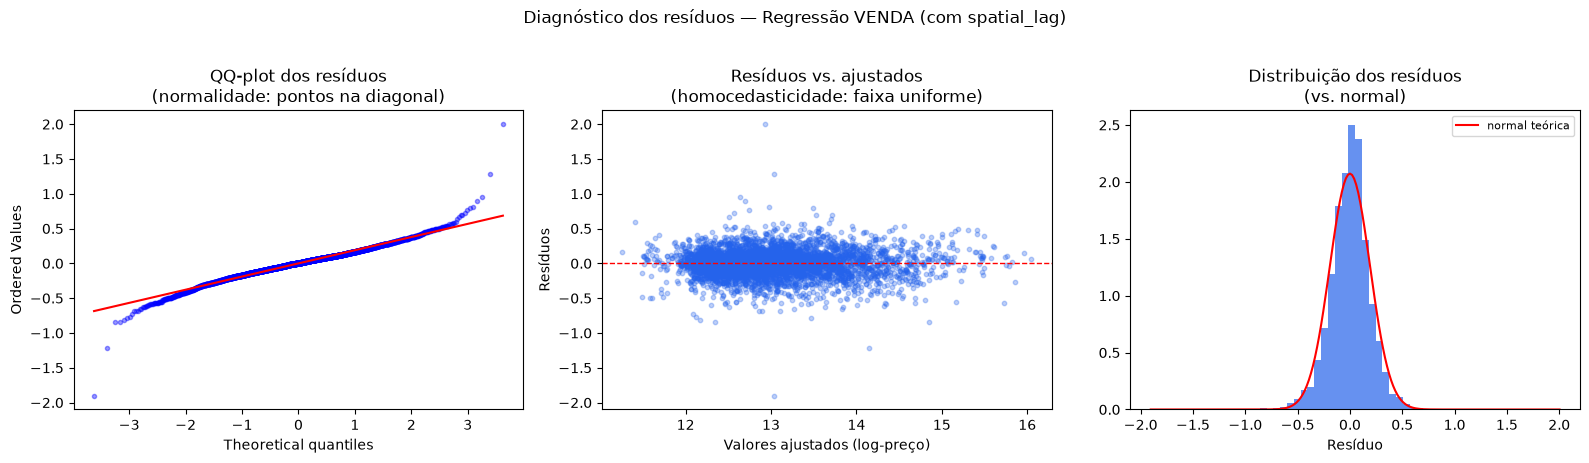

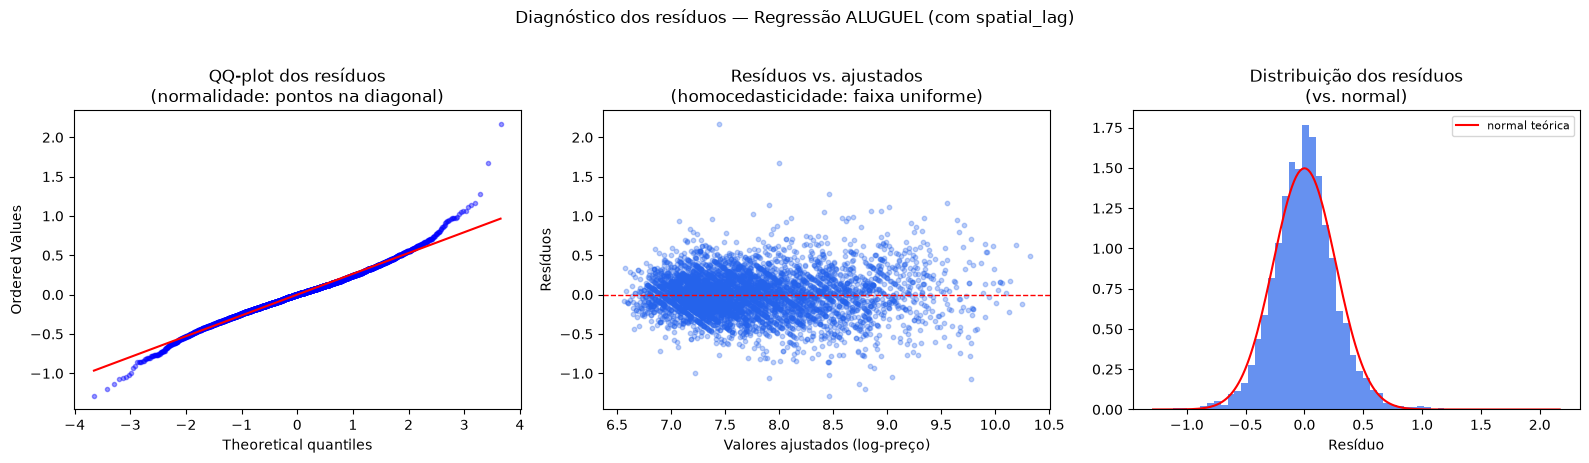

In [23]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

def plots_diagnostico(modelo_ols, rotulo):
    resid = modelo_ols.resid
    fitted = modelo_ols.fittedvalues

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(f"Diagnóstico dos resíduos — Regressão {rotulo} (com spatial_lag)",
                 fontsize=12, y=1.02)

    # 1. QQ-plot (normalidade)
    stats.probplot(resid, dist="norm", plot=axes[0])
    axes[0].set_title("QQ-plot dos resíduos\n(normalidade: pontos na diagonal)")
    axes[0].get_lines()[0].set_markersize(3)
    axes[0].get_lines()[0].set_alpha(0.4)

    # 2. Resíduos vs ajustados (homocedasticidade)
    axes[1].scatter(fitted, resid, alpha=0.3, s=10, color="#2563eb")
    axes[1].axhline(0, color="red", lw=1, ls="--")
    axes[1].set_xlabel("Valores ajustados (log-preço)")
    axes[1].set_ylabel("Resíduos")
    axes[1].set_title("Resíduos vs. ajustados\n(homocedasticidade: faixa uniforme)")

    # 3. Histograma dos resíduos (normalidade, complemento)
    axes[2].hist(resid, bins=60, color="#2563eb", alpha=0.7, density=True)
    # sobrepõe a normal teórica para comparação
    x = np.linspace(resid.min(), resid.max(), 200)
    axes[2].plot(x, stats.norm.pdf(x, resid.mean(), resid.std()),
                 "r-", lw=1.5, label="normal teórica")
    axes[2].set_xlabel("Resíduo")
    axes[2].set_title("Distribuição dos resíduos\n(vs. normal)")
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"outputs/diagnostico_residuos_{rotulo.lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

plots_diagnostico(mod_diag_v, "VENDA")
plots_diagnostico(mod_diag_a, "ALUGUEL")

#### Resultado — inspeção visual: violações reais, magnitude moderada

Os testes formais rejeitam normalidade e homocedasticidade (p≈0 nos dois mercados),
mas os gráficos mostram que a violação é **moderada na prática**:

- **Normalidade (QQ-plot + histograma):** o miolo dos resíduos adere bem à normal nos
  dois mercados; o desvio concentra-se nas **caudas** — curtose 9,1 (venda) / 5,2
  (aluguel). O modelo é bem-comportado no imóvel mediano e erra mais nos extremos
  (kitnets, coberturas de luxo). Venda tem cauda mais pesada que aluguel.
- **Homocedasticidade (resíduos vs. ajustados):** dispersão razoavelmente uniforme nos
  dois; sem o funil dramático de manual, apesar do Breusch-Pagan rejeitar. A rejeição
  formal reflete a sensibilidade do teste em amostra grande (~4.700-5.300 obs.), onde
  desvios pequenos são estatisticamente significativos.
- **Multicolinearidade (6.1, VIF):** moderada em Toilets/Suites/log_Size (5-7) — atributos
  de tamanho que dividem sinal. **Este é o fator que mais compromete a interpretação dos
  coeficientes individuais.**

> **Conclusão metodológica:** as violações são reais mas moderadas. Mesmo assim, a
> combinação de multicolinearidade (coeficientes instáveis) e não-normalidade (erros-padrão
> não-confiáveis) **inviabiliza a interpretação de coeficientes individuais** — por isso o
> "o que dirige o preço" vem do SHAP do XGBoost. E as limitações nos pressupostos, somadas à
> menor acurácia, **justificam complementar a regressão com ML** — que não exige esses
> pressupostos e erra menos nos extremos (onde a cauda pesada mostra que a regressão sofre).

## 7. Modelos de árvore (Random Forest e XGBoost)

Testa H1: modelos de ML batem a regressão em acurácia — e a que custo de
interpretabilidade? Régua a bater (teste final, Seção 6): **15,98% venda /
21,67% aluguel** (regressão linear espacial). Todos os modelos são avaliados no
mesmo test intocado, com seleção de hiperparâmetros por CV.

A `distancia_estacao` e a `renda_area` — ambas redundantes na regressão linear —
retornam aqui para teste nas árvores, que captam não-linearidades e interações que
a forma linear não expressa (protocolo "com vs. sem" para cada uma).

### 7.1 — Infraestrutura: CV anti-leakage para qualquer estimador

A função `cv_modelo_espacial` generaliza a CV da Fase 3 para receber qualquer
estimador sklearn-compatível (RF, XGBoost). O spatial lag é reconstruído **dentro de
cada fold** (vizinhos só do fold-treino) — a disciplina anti-leakage que rege todo o
projeto. É a fundação reutilizada por toda a Fase 4.

In [24]:
from sklearn.base import clone

def cv_modelo_espacial(estimator, df, X_train_full, y_train_log_full, k,
                       n_folds=5, usa_renda=False, usa_lag=True,
                       usa_distancia=False):
    """
    CV anti-leakage para QUALQUER estimador sklearn-compatível.
    O spatial lag é reconstruído dentro de cada fold (vizinhos só do fold-treino).
    Retorna array com o MAPE de cada fold.
    """
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    y_train_reais_full = np.expm1(y_train_log_full)

    mapes = []
    for idx_tr, idx_val in kf.split(X_train_full):
        X_ftr  = X_train_full.iloc[idx_tr]
        X_fval = X_train_full.iloc[idx_val]
        y_ftr_log    = y_train_log_full.iloc[idx_tr]
        y_fval_reais = y_train_reais_full.iloc[idx_val]

        Xtr, Xval = X_ftr.copy(), X_fval.copy()

        if usa_renda:
            Xtr["renda_area"]  = np.log1p(df.loc[Xtr.index,  "renda_area"])
            Xval["renda_area"] = np.log1p(df.loc[Xval.index, "renda_area"])

        if usa_distancia:
            Xtr["distancia_estacao"]  = df.loc[Xtr.index,  "distancia_estacao"]
            Xval["distancia_estacao"] = df.loc[Xval.index, "distancia_estacao"]

        if usa_lag:
            # ANTI-LEAKAGE: fonte de vizinhos = fold-treino; fold-validação é o "teste".
            lag_tr, lag_val = construir_spatial_lag(df, X_ftr, X_fval, y_ftr_log, k)
            Xtr["spatial_lag"]  = lag_tr
            Xval["spatial_lag"] = lag_val

        # clone() = estimador zerado a cada fold (sem estado vazado entre folds).
        modelo = clone(estimator).fit(Xtr, y_ftr_log)
        pred = np.expm1(modelo.predict(Xval))
        mapes.append(mean_absolute_percentage_error(y_fval_reais, pred))

    return np.array(mapes)

In [25]:
print("distancia_estacao em df_venda:  ", "distancia_estacao" in df_venda.columns)
print("distancia_estacao em df_aluguel:", "distancia_estacao" in df_aluguel.columns)
print("NaN em distancia (venda):       ", df_venda["distancia_estacao"].isna().sum() if "distancia_estacao" in df_venda.columns else "coluna ausente")

distancia_estacao em df_venda:   True
distancia_estacao em df_aluguel: True
NaN em distancia (venda):        0


### 7.2 — Random Forest: busca de hiperparâmetros por CV anti-leakage

Régua a bater: 15,98% venda / 21,67% aluguel (regressão linear espacial).
Busca em grade enxuta sobre max_depth, min_samples_leaf, max_features — os três
controles de overfitting que movem o RF. Loop manual (não GridSearchCV) porque a
CV precisa reconstruir o spatial lag por fold. A busca inclui distancia_estacao e
renda_area (log) na matriz — o teste da Seção 7.2.2 confirma que ambas agregam nas
árvores, ao contrário da regressão linear.


In [26]:
from sklearn.ensemble import RandomForestRegressor
from itertools import product

def buscar_rf(df, X_train_full, y_train_log_full, k, rotulo,
              usa_distancia=False, n_folds=5):
    grade = {
        "max_depth":        [10, 20, None],
        "min_samples_leaf": [1, 5, 20],
        "max_features":     ["sqrt", 0.33],
    }
    combos = list(product(grade["max_depth"],
                          grade["min_samples_leaf"],
                          grade["max_features"]))

    print(f"=== {rotulo} — RF | distancia={usa_distancia} | {len(combos)} combos ===")
    melhor = (None, 1.0, None)
    for depth, leaf, mf in combos:
        rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=depth,
            min_samples_leaf=leaf,
            max_features=mf,
            random_state=42,
            n_jobs=-1,
        )
        mapes = cv_modelo_espacial(
            rf, df, X_train_full, y_train_log_full, k,
            n_folds=n_folds, usa_renda=True, usa_lag=True,
            usa_distancia=usa_distancia,
        )
        media, desvio = mapes.mean(), mapes.std()
        marca = ""
        if media < melhor[1]:
            melhor = ((depth, leaf, mf), media, desvio); marca = " ←"
        print(f"  depth={str(depth):>4} leaf={leaf:>2} mf={str(mf):>4} "
              f"| MAPE CV: {media:6.2%} ± {desvio:5.2%}{marca}")
    p, m, d = melhor
    print(f"  → melhor: {p} | MAPE {m:.2%} ± {d:.2%}\n")
    return melhor

# k=3 (fixado — k=5 bate k=3 por 0,03 p.p. na venda sem renda, dentro do ruído).
# Árvores usam renda_area (CV prova ganho ~0,4 p.p.). Roda SEM distância primeiro.
melhor_rf_v = buscar_rf(df_venda,   X_train_v, y_train_v_log, 3, "VENDA",   usa_distancia=False)
melhor_rf_a = buscar_rf(df_aluguel, X_train_a, y_train_a_log, 3, "ALUGUEL", usa_distancia=False)


=== VENDA — RF | distancia=False | 18 combos ===
  depth=  10 leaf= 1 mf=sqrt | MAPE CV: 18.00% ± 0.68% ←
  depth=  10 leaf= 1 mf=0.33 | MAPE CV: 15.24% ± 0.60% ←
  depth=  10 leaf= 5 mf=sqrt | MAPE CV: 18.71% ± 0.69%
  depth=  10 leaf= 5 mf=0.33 | MAPE CV: 15.73% ± 0.61%
  depth=  10 leaf=20 mf=sqrt | MAPE CV: 21.72% ± 0.83%
  depth=  10 leaf=20 mf=0.33 | MAPE CV: 16.89% ± 0.51%
  depth=  20 leaf= 1 mf=sqrt | MAPE CV: 15.00% ± 0.61% ←
  depth=  20 leaf= 1 mf=0.33 | MAPE CV: 14.39% ± 0.52% ←
  depth=  20 leaf= 5 mf=sqrt | MAPE CV: 17.39% ± 0.63%
  depth=  20 leaf= 5 mf=0.33 | MAPE CV: 15.49% ± 0.58%
  depth=  20 leaf=20 mf=sqrt | MAPE CV: 21.47% ± 0.84%
  depth=  20 leaf=20 mf=0.33 | MAPE CV: 16.89% ± 0.52%
  depth=None leaf= 1 mf=sqrt | MAPE CV: 14.43% ± 0.57%
  depth=None leaf= 1 mf=0.33 | MAPE CV: 14.37% ± 0.59% ←
  depth=None leaf= 5 mf=sqrt | MAPE CV: 17.26% ± 0.63%
  depth=None leaf= 5 mf=0.33 | MAPE CV: 15.49% ± 0.60%
  depth=None leaf=20 mf=sqrt | MAPE CV: 21.47% ± 0.84%
  dept

#### Resultado — RF supera a régua linear; max_features é o parâmetro crítico

| Modelo | Melhor config | MAPE CV | Régua linear (CV) |
|--------|---------------|---------|-------------------|
| **Venda** | depth=None, leaf=1, mf=0.33 | **14,37% ± 0,59%** | 15,26% |
| **Aluguel** | depth=None, leaf=1, mf=sqrt | **20,04% ± 0,47%** | 21,37% |

RF bate a régua nos dois (~0,9–1,3 p.p. em CV). Confirmar no test final.

Achados:
- **max_features domina.** Na venda, 0.33 ganha de sqrt em quase todo combo
  (até 5 p.p.): as ~95 dummies de District + renda + lag ocupam o espaço, e sqrt
  (~10 de 107 colunas) sorteia os preditores fortes com frequência baixa demais.
  Evidência para target encoding do District (Seção 7.5).
- **Aluguel inverte:** sqrt ganha (20,04 vs 20,53). Features fortes são mais fracas
  no aluguel → descorrelação rende mais que dar-lhes palco. Coerente com H3.
- **leaf=1 + depth alto vencem:** RF regulariza por média descorrelacionada, não por
  poda. max_features é o regularizador que importa aqui (≠ XGBoost).

> **Melhor RF (CV, sem distância): venda 14,37% / aluguel 20,04%.** Falta: testar
> com distancia_estacao (7.2.1) e confirmar renda (7.2.2).


In [27]:
def rf_com_distancia(df, X_train_full, y_train_log_full, k, melhor_config, rotulo):
    depth, leaf, mf = melhor_config
    print(f"=== {rotulo} — efeito da distancia_estacao (RF {melhor_config}) ===")
    for usa_dist in [False, True]:
        rf = RandomForestRegressor(n_estimators=200, max_depth=depth,
                                   min_samples_leaf=leaf, max_features=mf,
                                   random_state=42, n_jobs=-1)
        mapes = cv_modelo_espacial(rf, df, X_train_full, y_train_log_full, k,
                                   usa_lag=True, usa_distancia=usa_dist,
                                   usa_renda=True)
        print(f"  distancia={str(usa_dist):>5} | MAPE CV: {mapes.mean():6.2%} ± {mapes.std():5.2%}")
    print()

rf_com_distancia(df_venda,   X_train_v, y_train_v_log, 3, melhor_rf_v[0], "VENDA")
rf_com_distancia(df_aluguel, X_train_a, y_train_a_log, 3, melhor_rf_a[0], "ALUGUEL")


=== VENDA — efeito da distancia_estacao (RF (None, 1, 0.33)) ===
  distancia=False | MAPE CV: 14.37% ± 0.59%
  distancia= True | MAPE CV: 14.23% ± 0.62%

=== ALUGUEL — efeito da distancia_estacao (RF (None, 1, 'sqrt')) ===
  distancia=False | MAPE CV: 20.04% ± 0.47%
  distancia= True | MAPE CV: 19.75% ± 0.51%



#### Resultado — distancia_estacao agrega nas árvores (mas não na regressão)

| Modelo | RF sem distância | RF com distância | Δ |
|--------|------------------|------------------|---|
| **Venda** | 14,37% | **14,23%** | −0,14 p.p. |
| **Aluguel** | 20,04% | **19,75%** | −0,29 p.p. |

A mesma feature deu ganho NULO na regressão (+0,06 p.p.). A árvore captura a
não-linearidade (distância satura longe da estação) e a interação (efeito depende
do bairro) que o modelo linear não vê. Ilustração direta do trade-off
interpretabilidade × acurácia — a tese do projeto.

> **Decisão: distancia_estacao entra no modelo de árvore.** A seguir, testa-se a
> renda (Seção 7.2.2) — mesma hipótese: ganho linear marginal, mas possível ganho
> não-linear nas árvores.

Vamos realizar um pequeno teste agora com a renda média, uma variável que não entrou na regressão baseline


In [28]:
def rf_renda_nas_arvores(df, X_train_full, y_train_log_full, k, melhor_config, rotulo):
    depth, leaf, mf = melhor_config
    print(f"=== {rotulo} — renda agrega na árvore? (RF {melhor_config}) ===")
    for usa_renda in [False, True]:
        rf = RandomForestRegressor(n_estimators=200, max_depth=depth,
                                   min_samples_leaf=leaf, max_features=mf,
                                   random_state=42, n_jobs=-1)
        mapes = cv_modelo_espacial(rf, df, X_train_full, y_train_log_full, k,
                                   usa_lag=True, usa_distancia=True,  # ambos já dentro
                                   usa_renda=usa_renda)
        print(f"  renda={str(usa_renda):>5} | MAPE CV: {mapes.mean():6.2%} ± {mapes.std():5.2%}")
    print()

rf_renda_nas_arvores(df_venda,   X_train_v, y_train_v_log, 3, melhor_rf_v[0], "VENDA")
rf_renda_nas_arvores(df_aluguel, X_train_a, y_train_a_log, 3, melhor_rf_a[0], "ALUGUEL")

=== VENDA — renda agrega na árvore? (RF (None, 1, 0.33)) ===
  renda=False | MAPE CV: 15.04% ± 0.52%
  renda= True | MAPE CV: 14.23% ± 0.62%

=== ALUGUEL — renda agrega na árvore? (RF (None, 1, 'sqrt')) ===
  renda=False | MAPE CV: 20.17% ± 0.53%
  renda= True | MAPE CV: 19.75% ± 0.51%



#### Resultado — renda agrega nas árvores (confirma hipótese de não-linearidade)

| Modelo | RF sem renda | RF com renda | Δ |
|--------|--------------|--------------|---|
| **Venda** (None, 1, mf=0.33) | 15,04% | **14,23%** | −0,81 p.p. |
| **Aluguel** (None, 1, mf=sqrt) | 20,17% | **19,75%** | −0,42 p.p. |

O mesmo padrão da distância: ganho pequeno na regressão linear (~0,1 p.p.),
**ganho real nas árvores** (~0,4–0,8 p.p.). Mecanismo: árvores captam a
não-linearidade da renda (saturação nos extremos, interação com tipo/tamanho
de imóvel e localização) que a regressão linear não expressa.

> **Decisão: renda_area (log) entra na matriz de árvore.** Matriz de árvore final:
> **baseline + spatial_lag (k=3) + distancia_estacao + renda_area (log).**
> 107 features (venda) / 105 (aluguel). A renda segue o mesmo status da
> distância: fora da regressão, dentro das árvores.

### 7.3 — XGBoost: busca por CV anti-leakage

Boosting = árvores em sequência, cada uma corrige o resíduo da anterior. Candidato
a campeão pela literatura BR. Régua a bater: RF (CV) venda 14,23% / aluguel 19,75%.
Hiperparâmetros na lógica do boosting (≠ RF): learning_rate baixo + árvores rasas
+ subsample/colsample para regularizar. Grade fixa nesta rodada (early stopping
fica para o refino). Matriz = baseline + spatial_lag (k=3) + distancia_estacao
+ renda_area (log).


In [29]:
from xgboost import XGBRegressor

def buscar_xgb(df, X_train_full, y_train_log_full, k, rotulo, n_folds=5):
    grade = {
        "learning_rate": [0.05, 0.1],
        "max_depth":     [4, 6, 8],
        "n_estimators":  [300, 600],
    }
    combos = list(product(grade["learning_rate"],
                          grade["max_depth"],
                          grade["n_estimators"]))

    print(f"=== {rotulo} — XGBoost | {len(combos)} combos ===")
    melhor = (None, 1.0, None)
    for lr, depth, n_est in combos:
        xgb = XGBRegressor(
            learning_rate=lr,
            max_depth=depth,
            n_estimators=n_est,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
        )
        mapes = cv_modelo_espacial(
            xgb, df, X_train_full, y_train_log_full, k,
            usa_lag=True, usa_distancia=True, usa_renda=True,
        )
        media, desvio = mapes.mean(), mapes.std()
        marca = ""
        if media < melhor[1]:
            melhor = ((lr, depth, n_est), media, desvio); marca = " ←"
        print(f"  lr={lr:<4} depth={depth} n={n_est:>3} "
              f"| MAPE CV: {media:6.2%} ± {desvio:5.2%}{marca}")
    p, m, d = melhor
    print(f"  → melhor: lr={p[0]}, depth={p[1]}, n={p[2]} | MAPE {m:.2%} ± {d:.2%}\n")
    return melhor

melhor_xgb_v = buscar_xgb(df_venda,   X_train_v, y_train_v_log, 3, "VENDA")
melhor_xgb_a = buscar_xgb(df_aluguel, X_train_a, y_train_a_log, 3, "ALUGUEL")


=== VENDA — XGBoost | 12 combos ===
  lr=0.05 depth=4 n=300 | MAPE CV: 14.50% ± 0.63% ←
  lr=0.05 depth=4 n=600 | MAPE CV: 14.08% ± 0.59% ←
  lr=0.05 depth=6 n=300 | MAPE CV: 14.00% ± 0.62% ←
  lr=0.05 depth=6 n=600 | MAPE CV: 13.79% ± 0.60% ←
  lr=0.05 depth=8 n=300 | MAPE CV: 13.87% ± 0.54%
  lr=0.05 depth=8 n=600 | MAPE CV: 13.82% ± 0.56%
  lr=0.1  depth=4 n=300 | MAPE CV: 14.12% ± 0.52%
  lr=0.1  depth=4 n=600 | MAPE CV: 13.87% ± 0.47%
  lr=0.1  depth=6 n=300 | MAPE CV: 13.95% ± 0.55%
  lr=0.1  depth=6 n=600 | MAPE CV: 14.03% ± 0.60%
  lr=0.1  depth=8 n=300 | MAPE CV: 13.95% ± 0.58%
  lr=0.1  depth=8 n=600 | MAPE CV: 14.06% ± 0.60%
  → melhor: lr=0.05, depth=6, n=600 | MAPE 13.79% ± 0.60%

=== ALUGUEL — XGBoost | 12 combos ===
  lr=0.05 depth=4 n=300 | MAPE CV: 20.69% ± 0.31% ←
  lr=0.05 depth=4 n=600 | MAPE CV: 20.23% ± 0.26% ←
  lr=0.05 depth=6 n=300 | MAPE CV: 20.10% ± 0.15% ←
  lr=0.05 depth=6 n=600 | MAPE CV: 19.76% ± 0.16% ←
  lr=0.05 depth=8 n=300 | MAPE CV: 19.93% ± 0.23%
 

#### Resultado — XGBoost vence na venda, empata o RF no aluguel

| Modelo | RF (CV) | XGBoost (CV) | melhor config XGB |
|--------|---------|--------------|-------------------|
| **Venda** | 14,23% | **13,79% ± 0,60%** | lr=0.05, depth=6, n=600 |
| **Aluguel** | 19,75% | **19,76% ± 0,16%** | lr=0.05, depth=6, n=600 |

- **Venda:** XGB ganha 0,44 p.p. do RF (ICs quase disjuntos) — boosting > bagging,
  como a literatura BR prevê.
- **Aluguel:** empate técnico (0,01 p.p.). O boosting não extrai sinal que o RF já
  não tenha — coerente com aluguel mais ruidoso (H3).
- **Overfit visível:** lr=0.1 + n=600 piora vs n=300; lr=0.05 + n=600 ainda melhora.
  → lr=0.05 é o caminho, e early stopping deve render no refino.

> **Provisório (CV):** campeão venda = XGBoost 13,79%; campeão aluguel = RF/XGB
> empatados em ~19,75%. Refinar XGB com early stopping (lr=0.05) antes do test final.

### 7.4 — XGBoost com early stopping (sub-split anti-leakage)

A grade fixa apontou lr=0.05 e n>600 ainda melhorando. Early stopping acha o n
ótimo sozinho. Custo: um 3º nível de split (sub-treino/sub-validação dentro de
cada fold-treino) para o XGB observar onde parar, sem tocar o fold-validação.
O spatial lag é reconstruído DUAS vezes por fold: uma no sub-split (achar n),
outra no fold-treino inteiro (treinar o modelo final e medir).

In [30]:
from sklearn.model_selection import train_test_split

def cv_xgb_early_stopping(df, X_train_full, y_train_log_full, k, rotulo,
                          lr=0.05, max_depth=6, n_max=2000,
                          early_rounds=50, n_folds=5, usa_distancia=True,
                          usa_renda=False):
    """
    CV do XGBoost com early stopping anti-leakage.
    Três níveis: fold-treino/fold-validação (CV) e, dentro do fold-treino,
    sub-treino/sub-validação (onde o early stopping observa).
    O spatial lag é reconstruído em cada par (vizinhos só do conjunto-treino do par).
    Retorna (array de MAPE por fold, lista de n_árvores escolhido por fold).
    """
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    y_reais_full = np.expm1(y_train_log_full)

    def montar_X(X_base, df, lag_vals):
        """Anexa spatial_lag, distância e renda conforme configuração."""
        Xc = X_base.copy()
        Xc["spatial_lag"] = lag_vals
        if usa_distancia:
            Xc["distancia_estacao"] = df.loc[Xc.index, "distancia_estacao"]
        if usa_renda:
            Xc["renda_area"] = np.log1p(df.loc[Xc.index, "renda_area"])
        return Xc

    mapes, ns_escolhidos = [], []
    for idx_tr, idx_val in kf.split(X_train_full):
        X_ftr  = X_train_full.iloc[idx_tr]
        X_fval = X_train_full.iloc[idx_val]
        y_ftr_log = y_train_log_full.iloc[idx_tr]
        y_fval_reais = y_reais_full.iloc[idx_val]

        X_str, X_sval, y_str_log, y_sval_log = train_test_split(
            X_ftr, y_ftr_log, test_size=0.2, random_state=42
        )

        lag_str, lag_sval = construir_spatial_lag(df, X_str, X_sval, y_str_log, k)
        X_str_m  = montar_X(X_str,  df, lag_str)
        X_sval_m = montar_X(X_sval, df, lag_sval)

        modelo = XGBRegressor(
            learning_rate=lr, max_depth=max_depth, n_estimators=n_max,
            subsample=0.8, colsample_bytree=0.8,
            objective="reg:squarederror", eval_metric="rmse",
            early_stopping_rounds=early_rounds,
            random_state=42, n_jobs=-1, tree_method="hist",
        )
        modelo.fit(X_str_m, y_str_log,
                   eval_set=[(X_sval_m, y_sval_log)], verbose=False)
        n_otimo = modelo.best_iteration + 1
        ns_escolhidos.append(n_otimo)

        lag_ftr, lag_fval = construir_spatial_lag(df, X_ftr, X_fval, y_ftr_log, k)
        X_ftr_m  = montar_X(X_ftr,  df, lag_ftr)
        X_fval_m = montar_X(X_fval, df, lag_fval)

        modelo_final = XGBRegressor(
            learning_rate=lr, max_depth=max_depth, n_estimators=n_otimo,
            subsample=0.8, colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42, n_jobs=-1, tree_method="hist",
        )
        modelo_final.fit(X_ftr_m, y_ftr_log, verbose=False)
        pred = np.expm1(modelo_final.predict(X_fval_m))
        mapes.append(mean_absolute_percentage_error(y_fval_reais, pred))

    mapes = np.array(mapes)
    print(f"=== {rotulo} — XGB early stopping (lr={lr}, depth={max_depth}) ===")
    print(f"  n_árvores por fold: {ns_escolhidos}")
    print(f"  MAPE CV: {mapes.mean():6.2%} ± {mapes.std():5.2%}\n")
    return mapes, ns_escolhidos

mapes_es_v, ns_v = cv_xgb_early_stopping(df_venda,   X_train_v, y_train_v_log, 3, "VENDA",
                                          usa_renda=True)
mapes_es_a, ns_a = cv_xgb_early_stopping(df_aluguel, X_train_a, y_train_a_log, 3, "ALUGUEL",
                                          usa_renda=True)


=== VENDA — XGB early stopping (lr=0.05, depth=6) ===
  n_árvores por fold: [238, 373, 436, 514, 535]
  MAPE CV: 13.94% ± 0.67%

=== ALUGUEL — XGB early stopping (lr=0.05, depth=6) ===
  n_árvores por fold: [451, 516, 311, 378, 504]
  MAPE CV: 19.96% ± 0.21%



#### Resultado — early stopping não supera a grade fixa

| Modelo | Grade fixa (n=600) | Early stopping | n médio escolhido (ES) |
|--------|--------------------|--------------------|------------------------|
| **Venda** | **13,79%** | 13,94% | ~419 |
| **Aluguel** | **19,76%** | 19,96% | ~432 |

O early stopping parou antes de 600 árvores (observa a sub-validação, conjunto
menor → sinal de parada mais ruidoso → para cedo). As ~180 árvores extras da grade
fixa ajudavam o fold-validação marginalmente. Resultado negativo válido: a
complexidade do sub-split anti-leakage não compensou nesta escala.

> **Campeão XGBoost (CV): grade fixa lr=0.05, depth=6, n=600.** Venda 13,79% /
> aluguel 19,76%. Early stopping testado e descartado por não agregar.


### 7.5 — Infraestrutura: target encoding anti-leakage do District

A seção 7.2 identificou que as ~95 dummies de District "sufocam" o `max_features`
do RF. Target encoding comprime o District numa única coluna (a média do alvo por
bairro), liberando espaço amostral por split.

**Risco:** se o encoding vazar o alvo de validação, o modelo aprende a "prever"
sem generalizar. Solução: out-of-fold no treino + média do treino inteiro (suavizada)
no teste.

`construir_target_encoding()` implementa isso:
- **Treino:** cada imóvel recebe a média de bairro calculada nas *outras* dobras (K-fold
  interno) — nunca vê o próprio alvo.
- **Teste:** lookup das médias do treino inteiro, com suavização bayesiana
  (`alpha=10`) para bairros com poucos imóveis.
- **Sanidade:** correlação moderada e positiva entre encoding e alvo confirma sinal
  real; correlação ~1.0 indicaria leakage.

`cv_modelo_te()` estende a CV anti-leakage existente para alternar entre one-hot
e target encoding por fold, mantendo a reconstrução do spatial lag.

In [31]:
def construir_target_encoding(df, X_train, X_test, y_train_log,
                              col="District", n_folds_interno=5, alpha=10):
    """
    Target encoding anti-leakage do District.
    Treino: out-of-fold (média de cada imóvel exclui ele próprio via K-fold interno).
    Teste: lookup das médias aprendidas no treino inteiro.
    Suavização (alpha): bairros com poucos imóveis puxam para a média global,
    evitando médias instáveis baseadas em 1-2 observações.
    Retorna (série encoded p/ treino, série encoded p/ teste), alinhadas por índice.
    """
    bairros_tr = df.loc[X_train.index, col]
    bairros_te = df.loc[X_test.index, col]
    y = pd.Series(y_train_log.values, index=X_train.index)
    media_global = y.mean()

    # --- TESTE: média por bairro no treino INTEIRO, com suavização ---
    stats = y.groupby(bairros_tr).agg(["mean", "count"])
    # smoothing: (n*média_bairro + alpha*média_global) / (n + alpha)
    suave = (stats["count"] * stats["mean"] + alpha * media_global) / (stats["count"] + alpha)
    enc_test = bairros_te.map(suave).fillna(media_global)  # bairro inédito → global

    # --- TREINO: out-of-fold (cada imóvel recebe média das OUTRAS dobras) ---
    enc_train = pd.Series(index=X_train.index, dtype=float)
    kf = KFold(n_splits=n_folds_interno, shuffle=True, random_state=42)
    for idx_in, idx_out in kf.split(X_train):
        # treina o encoding nas dobras "in", aplica nas "out"
        b_in  = bairros_tr.iloc[idx_in]
        y_in  = y.iloc[idx_in]
        b_out = bairros_tr.iloc[idx_out]
        s = y_in.groupby(b_in).agg(["mean", "count"])
        suave_in = (s["count"] * s["mean"] + alpha * media_global) / (s["count"] + alpha)
        enc_train.iloc[idx_out] = b_out.map(suave_in).fillna(media_global).values

    return enc_train, enc_test


# --- TESTE DE SANIDADE ---
enc_tr, enc_te = construir_target_encoding(df_venda, X_train_v, X_test_v, y_train_v_log)
print("Target encoding — sanidade (venda):")
print(f"  treino: média {enc_tr.mean():.3f} | min {enc_tr.min():.3f} | max {enc_tr.max():.3f} | NaN {enc_tr.isna().sum()}")
print(f"  teste:  média {enc_te.mean():.3f} | min {enc_te.min():.3f} | max {enc_te.max():.3f} | NaN {enc_te.isna().sum()}")
print(f"  alvo log médio: {y_train_v_log.mean():.3f}  (encoding deve orbitar isso)")
# correlação encoding x alvo no treino: deve ser POSITIVA mas NÃO ~1.0
corr = np.corrcoef(enc_tr.values, y_train_v_log.values)[0, 1]
print(f"  corr(encoding, alvo) no treino: {corr:.3f}  (positiva e moderada = ok; ~1.0 = leakage)")

Target encoding — sanidade (venda):
  treino: média 13.029 | min 11.906 | max 14.265 | NaN 0
  teste:  média 13.002 | min 11.886 | max 14.241 | NaN 0
  alvo log médio: 13.018  (encoding deve orbitar isso)
  corr(encoding, alvo) no treino: 0.761  (positiva e moderada = ok; ~1.0 = leakage)


In [32]:
def cv_modelo_te(estimator, df, X_train_full, y_train_log_full, k,
                 rotulo, usa_target_encoding=True, usa_renda=False, n_folds=5):
    """
    CV anti-leakage para comparação one-hot vs target encoding do District.
    Sempre inclui distancia_estacao e spatial_lag (reconstruído por fold).
    Se usa_renda=True: adiciona renda_area em log (mesmo mecanismo da distância).
    Se usa_target_encoding=True: remove District_*, injeta district_te out-of-fold.
    Retorna MAPE médio dos folds (escalar).
    """
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    y_reais_full = np.expm1(y_train_log_full)
    cols_district = [c for c in X_train_full.columns if c.startswith("District_")]
    mapes = []
    for idx_tr, idx_val in kf.split(X_train_full):
        X_ftr  = X_train_full.iloc[idx_tr]
        X_fval = X_train_full.iloc[idx_val]
        y_ftr_log    = y_train_log_full.iloc[idx_tr]
        y_fval_reais = y_reais_full.iloc[idx_val]

        Xtr, Xval = X_ftr.copy(), X_fval.copy()

        if usa_target_encoding:
            enc_tr, enc_val = construir_target_encoding(
                df, X_ftr, X_fval, y_ftr_log, col="District"
            )
            Xtr  = Xtr.drop(columns=cols_district)
            Xval = Xval.drop(columns=cols_district)
            Xtr["district_te"]  = enc_tr
            Xval["district_te"] = enc_val

        if usa_renda:
            Xtr["renda_area"]  = np.log1p(df.loc[Xtr.index,  "renda_area"])
            Xval["renda_area"] = np.log1p(df.loc[Xval.index, "renda_area"])

        Xtr["distancia_estacao"]  = df.loc[Xtr.index,  "distancia_estacao"]
        Xval["distancia_estacao"] = df.loc[Xval.index, "distancia_estacao"]

        lag_tr, lag_val = construir_spatial_lag(df, X_ftr, X_fval, y_ftr_log, k)
        Xtr["spatial_lag"]  = lag_tr
        Xval["spatial_lag"] = lag_val

        modelo = clone(estimator).fit(Xtr, y_ftr_log)
        pred = np.expm1(modelo.predict(Xval))
        mapes.append(mean_absolute_percentage_error(y_fval_reais, pred))

    print(f"  {rotulo:40} | MAPE CV: {np.mean(mapes):.2%} ± {np.std(mapes):.2%}")
    return np.mean(mapes)



In [33]:
# Como se chamam as colunas de District no X_train?
cols_district = [c for c in X_train_v.columns if c.startswith("District")]
print(f"Nº de colunas District: {len(cols_district)}")
print("Exemplos:", cols_district[:3])
print("Total de colunas em X_train_v:", X_train_v.shape[1])

Nº de colunas District: 95
Exemplos: ['District_Alto de Pinheiros/São Paulo', 'District_Anhanguera/São Paulo', 'District_Aricanduva/São Paulo']
Total de colunas em X_train_v: 104


### 7.6 — One-hot vs. target encoding, cada um no seu ótimo (CV)

Comparação honesta: one-hot (~107/105 colunas venda/aluguel, com renda incluída, config já vencedora)
vs. target encoding (~12/10 colunas, max_features/colsample re-varridos para o
espaço comprimido). Em 11
features, usar todas por split (1.0) volta a ser viável — a liberdade que o TE compra
ao eliminar as 95 dummies. Se o TE no ótimo dele bater o one-hot no ótimo dele, o
sufocamen

In [34]:
def buscar_encoding(df, X_train, y_train_log, rotulo,
                    config_rf_onehot, config_xgb_onehot=(0.05, 6, 600)):
    print(f"=== {rotulo} — busca por cenário ===")

    depth, leaf, mf_oh = config_rf_onehot
    lr, dpt, n = config_xgb_onehot

    rf_oh = RandomForestRegressor(n_estimators=200, max_depth=depth,
                                  min_samples_leaf=leaf, max_features=mf_oh,
                                  random_state=42, n_jobs=-1)
    m_rf_oh = cv_modelo_te(rf_oh, df, X_train, y_train_log, 3,
                           f"RF  one-hot (mf={mf_oh})", usa_target_encoding=False,
                           usa_renda=True)

    xgb_oh = XGBRegressor(learning_rate=lr, max_depth=dpt, n_estimators=n,
                          subsample=0.8, colsample_bytree=0.8,
                          objective="reg:squarederror", random_state=42,
                          n_jobs=-1, tree_method="hist")
    m_xgb_oh = cv_modelo_te(xgb_oh, df, X_train, y_train_log, 3,
                            "XGB one-hot (cs=0.8)", usa_target_encoding=False,
                            usa_renda=True)

    print(f"  {'-'*50}")
    melhor_rf_te = (None, 1.0)
    for mf in ["sqrt", 0.5, 1.0]:
        rf_te = RandomForestRegressor(n_estimators=200, max_depth=depth,
                                      min_samples_leaf=leaf, max_features=mf,
                                      random_state=42, n_jobs=-1)
        m = cv_modelo_te(rf_te, df, X_train, y_train_log, 3,
                         f"RF  target-enc (mf={mf})", usa_target_encoding=True,
                         usa_renda=True)
        if m < melhor_rf_te[1]:
            melhor_rf_te = (mf, m)

    melhor_xgb_te = (None, 1.0)
    for cs in [0.5, 0.8, 1.0]:
        xgb_te = XGBRegressor(learning_rate=lr, max_depth=dpt, n_estimators=n,
                              subsample=0.8, colsample_bytree=cs,
                              objective="reg:squarederror", random_state=42,
                              n_jobs=-1, tree_method="hist")
        m = cv_modelo_te(xgb_te, df, X_train, y_train_log, 3,
                         f"XGB target-enc (cs={cs})", usa_target_encoding=True,
                         usa_renda=True)
        if m < melhor_xgb_te[1]:
            melhor_xgb_te = (cs, m)

    print(f"  {'='*50}")
    print(f"  RF : one-hot {m_rf_oh:.2%} | melhor TE {melhor_rf_te[1]:.2%} "
          f"(mf={melhor_rf_te[0]}) → {'TE' if melhor_rf_te[1] < m_rf_oh else 'ONE-HOT'}")
    print(f"  XGB: one-hot {m_xgb_oh:.2%} | melhor TE {melhor_xgb_te[1]:.2%} "
          f"(cs={melhor_xgb_te[0]}) → {'TE' if melhor_xgb_te[1] < m_xgb_oh else 'ONE-HOT'}")
    print()
    return {"rf_oh": m_rf_oh, "rf_te": melhor_rf_te,
            "xgb_oh": m_xgb_oh, "xgb_te": melhor_xgb_te}

res_enc_v = buscar_encoding(df_venda,   X_train_v, y_train_v_log, "VENDA",   melhor_rf_v[0])
res_enc_a = buscar_encoding(df_aluguel, X_train_a, y_train_a_log, "ALUGUEL", melhor_rf_a[0])


=== VENDA — busca por cenário ===
  RF  one-hot (mf=0.33)                    | MAPE CV: 14.23% ± 0.62%
  XGB one-hot (cs=0.8)                     | MAPE CV: 13.79% ± 0.60%
  --------------------------------------------------
  RF  target-enc (mf=sqrt)                 | MAPE CV: 14.34% ± 0.49%
  RF  target-enc (mf=0.5)                  | MAPE CV: 14.23% ± 0.52%
  RF  target-enc (mf=1.0)                  | MAPE CV: 14.58% ± 0.61%
  XGB target-enc (cs=0.5)                  | MAPE CV: 13.89% ± 0.47%
  XGB target-enc (cs=0.8)                  | MAPE CV: 13.82% ± 0.48%
  XGB target-enc (cs=1.0)                  | MAPE CV: 13.92% ± 0.53%
  RF : one-hot 14.23% | melhor TE 14.23% (mf=0.5) → ONE-HOT
  XGB: one-hot 13.79% | melhor TE 13.82% (cs=0.8) → ONE-HOT

=== ALUGUEL — busca por cenário ===
  RF  one-hot (mf=sqrt)                    | MAPE CV: 19.75% ± 0.51%
  XGB one-hot (cs=0.8)                     | MAPE CV: 19.76% ± 0.16%
  --------------------------------------------------
  RF  target-

#### Resultado — target encoding não supera one-hot (cada um no seu ótimo)

| Modelo | One-hot (ótimo) | Melhor TE | Decisão |
|--------|-----------------|-----------|---------|
| RF venda | 14,23% (mf=0.33) | 14,23% (mf=0.5) | empate → one-hot |
| XGB venda | 13,79% (cs=0.8) | 13,82% (cs=0.8) | one-hot |
| RF aluguel | 19,75% (mf=sqrt) | 19,98% (mf=sqrt) | one-hot |
| XGB aluguel | 19,76% (cs=0.8) | 19,87% (cs=0.8) | one-hot |

Hipótese do "sufocamento das dummies" REFUTADA. Com renda e distância na matriz,
o one-hot (107/105 colunas) ainda vence ou empata o TE em todos os 4 casos. Na
venda, mf=0.33 resolve o problema do sorteio (26 de 107 = boa diversidade), sem
necessidade de comprimir o District. No aluguel, o TE perde granularidade (1 média
suavizada vs 93 efeitos independentes) e custa caro.

> **Decisão: one-hot do District mantido em todos os modelos.** Target encoding
> testado no ótimo de cada representação e descartado por não agregar. Frente de
> melhoria encerrada.


## 8. Teste de generalização final — comparação dos três modelos

Régua de avaliação única: o test set 20% intocado. Cada modelo foi selecionado
por CV no treino (k do spatial lag, hiperparâmetros, exclusão da renda da regressão
linear) sem nunca ver o test. Aqui cada um é treinado no treino completo e avaliado
UMA vez no test — o número de generalização que vai para o trabalho e responde H1
(ML supera a regressão?) e H3 (venda e aluguel têm dinâmicas distintas?).

### Os três modelos e suas matrizes

**1. Regressão linear múltipla (baseline normativo).**
Método consagrado pela NBR 14653 para avaliação de imóveis. Estima um preço
hedônico: o log do preço como soma de contribuições lineares dos atributos.
Interpretável e auditável (cada coeficiente é um preço implícito), mas cego a
não-linearidades e interações. Matriz: atributos físicos + District (one-hot) +
spatial_lag (k=3). **SEM distância e SEM renda** — ambas com ganho marginal (≤0,1 p.p.)
na forma linear; excluídas por parcimônia (lag extrai o sinal relevante).

**2. Random Forest (bagging).**
Muitas árvores independentes treinadas em subamostras aleatórias de linhas e
colunas; a predição é a média. Regulariza por descorrelação entre árvores
(max_features), não por poda — por isso usa árvores fundas (depth ilimitado,
folhas mínimas). Captura não-linearidades e interações que a regressão não vê, ao
custo de interpretabilidade. Config (por CV): venda max_features=0.33, aluguel
max_features=sqrt, depth=None, leaf=1.

**3. XGBoost (boosting).**
Árvores em sequência, cada uma corrigindo o resíduo da anterior. Estado da arte
para dados tabulares. Regulariza pelo passo de aprendizado (learning_rate baixo) e
árvores rasas — força vem de somar muitas árvores fracas, não de poucas fundas.
Config (por CV): lr=0.05, depth=6, n=600.

**Matriz das árvores (RF e XGB):** atributos físicos + District (one-hot) +
spatial_lag (k=3) + distancia_estacao + renda_area (log). **107 features (venda) /
105 (aluguel).** Distância e renda são inúteis na regressão (ganho linear ≤0,1 p.p.)
mas agregam nas árvores (~0,1–0,8 p.p.): elas captam não-linearidades (distância
satura longe da estação; renda tem efeito marginal decrescente) e interações que
o modelo linear não expressa.

**Encoding do District (testado):** as ~95/93 dummies one-hot foram comparadas a
target encoding (District comprimido em 1 coluna = preço médio log do bairro,
out-of-fold anti-leakage), cada representação com seu próprio max_features/colsample
re-tunado, com renda inclusa em ambos os casos. O one-hot venceu ou empatou em
todos os 4 cenários (RF venda, XGB venda, RF aluguel, XGB aluguel). Mantido o one-hot.


In [35]:
def treinar_e_avaliar_final(df, X_train, X_test, y_train_log, y_test_real,
                            k, modelo, usa_distancia, rotulo, usa_renda=False):
    """Treina no treino completo, avalia uma vez no test. Matriz conforme o modelo."""
    lag_tr, lag_te = construir_spatial_lag(df, X_train, X_test, y_train_log, k)
    Xtr, Xte = X_train.copy(), X_test.copy()
    Xtr["spatial_lag"], Xte["spatial_lag"] = lag_tr, lag_te
    if usa_distancia:
        Xtr["distancia_estacao"] = df.loc[Xtr.index, "distancia_estacao"]
        Xte["distancia_estacao"] = df.loc[Xte.index, "distancia_estacao"]
    if usa_renda:
        Xtr["renda_area"] = np.log1p(df.loc[Xtr.index, "renda_area"])
        Xte["renda_area"] = np.log1p(df.loc[Xte.index, "renda_area"])

    modelo.fit(Xtr, y_train_log)
    pred = np.expm1(modelo.predict(Xte))
    mape = mean_absolute_percentage_error(y_test_real, pred)
    mae  = np.mean(np.abs(y_test_real - pred))
    r2   = r2_score(y_test_real, pred)
    print(f"  {rotulo:16} | MAPE: {mape:6.2%} | MAE: R$ {mae:>9,.0f} | R²: {r2:.3f}")
    return {"modelo": rotulo, "mape": mape, "mae": mae, "r2": r2, "obj": modelo}


def comparar_final(df, X_train, X_test, y_train_log, y_test_real, k,
                   config_rf, config_xgb, rotulo):
    print(f"=== {rotulo} — TEST FINAL ===")
    resultados = []

    # 1. Regressão linear — SEM distância, SEM renda (hedônico puro + spatial lag)
    resultados.append(treinar_e_avaliar_final(
        df, X_train, X_test, y_train_log, y_test_real, k,
        LinearRegression(), usa_distancia=False, rotulo="Regressão linear"))

    # 2. Random Forest — COM distância e COM renda
    depth, leaf, mf = config_rf
    rf = RandomForestRegressor(n_estimators=200, max_depth=depth,
                               min_samples_leaf=leaf, max_features=mf,
                               random_state=42, n_jobs=-1)
    resultados.append(treinar_e_avaliar_final(
        df, X_train, X_test, y_train_log, y_test_real, k,
        rf, usa_distancia=True, rotulo="Random Forest", usa_renda=True))

    # 3. XGBoost — COM distância e COM renda
    lr, dpt, n_est = config_xgb
    xgb = XGBRegressor(learning_rate=lr, max_depth=dpt, n_estimators=n_est,
                       subsample=0.8, colsample_bytree=0.8,
                       objective="reg:squarederror", random_state=42,
                       n_jobs=-1, tree_method="hist")
    resultados.append(treinar_e_avaliar_final(
        df, X_train, X_test, y_train_log, y_test_real, k,
        xgb, usa_distancia=True, rotulo="XGBoost", usa_renda=True))
    print()
    return resultados


res_v = comparar_final(df_venda,   X_train_v, X_test_v, y_train_v_log, y_test_v,
                       3, melhor_rf_v[0], melhor_xgb_v[0], "VENDA")
res_a = comparar_final(df_aluguel, X_train_a, X_test_a, y_train_a_log, y_test_a,
                       3, melhor_rf_a[0], melhor_xgb_a[0], "ALUGUEL")


=== VENDA — TEST FINAL ===
  Regressão linear | MAPE: 15.98% | MAE: R$    96,358 | R²: 0.909
  Random Forest    | MAPE: 14.38% | MAE: R$    90,268 | R²: 0.897
  XGBoost          | MAPE: 14.04% | MAE: R$    84,982 | R²: 0.928

=== ALUGUEL — TEST FINAL ===
  Regressão linear | MAPE: 21.67% | MAE: R$       751 | R²: 0.741
  Random Forest    | MAPE: 19.91% | MAE: R$       739 | R²: 0.699
  XGBoost          | MAPE: 20.29% | MAE: R$       734 | R²: 0.740



### Resultado — comparação final dos três modelos (test 20% intocado)

| Modelo | Venda MAPE | Venda R² | Aluguel MAPE | Aluguel R² |
|--------|-----------|----------|--------------|------------|
| Regressão linear | 15,98% | 0,909 | 21,67% | 0,741 |
| Random Forest | 14,38% | 0,897 | **19,91%** | 0,699 |
| **XGBoost** | **14,04%** | **0,928** | 20,29% | 0,740 |

**H1 confirmado:** ML supera a regressão nos dois mercados (venda −1,94 p.p. via XGB;
aluguel −1,76 p.p. via RF). **H3 confirmado:** nos resultados de test, campeão difere
por mercado (XGB venda; RF aluguel).

- **Venda — XGBoost campeão limpo.** Domina nos três indicadores (MAPE, MAE, R²).
  MAE R$ 84.982 vs R$ 96.358 da regressão. Boosting > bagging, como a literatura BR prevê.
- **Aluguel — RF vence o test (19,91% vs 20,29%), mas XGBoost escolhido por
  consistência de produto.** Na CV, RF e XGB empatavam em 19,75%/19,76% — diferença
  de 0,01 p.p., totalmente dentro do ruído. O test revelou margem de 0,38 p.p. favorável
  ao RF, mas a incerteza de um único split e a vantagem operacional (mesmo algoritmo
  nos dois mercados → deploy e SHAP unificados) justificam manter o XGBoost.

> **Fase 4 ENCERRADA.** Campeão venda: **XGBoost (14,04% / R² 0,928)**.
> Campeão aluguel: **XGBoost (20,29% / R² 0,740)** por consistência de produto
> (RF 19,91% tecnicamente melhor no test; empate em CV). Modelos salvos em `models/`
> com 107 features (venda) e 105 (aluguel).

### Persistência dos modelos campeões

Os dois XGBoost campeões (venda e aluguel) são serializados em disco com `joblib`,
na pasta `models/`. Isso evita retreinar para servir a Fase 6 (Streamlit): o app
carregará esses arquivos diretamente.

> **Atenção (Fase 6):** o modelo salvo é apenas metade do necessário. Para precificar
> um imóvel novo, o app terá de reconstruir o `spatial_lag` em tempo real — ou seja,
> precisará também das coordenadas e preços do conjunto de treino para localizar os
> k vizinhos. O `.joblib` guarda o modelo; o "mapa de vizinhança" (treino) será
> persistido à parte na Fase 6.


In [36]:
import joblib
from pathlib import Path

Path("models").mkdir(exist_ok=True)

modelo_campeao_v = res_v[2]["obj"]   # XGBoost venda  — melhor MAPE test (14.04%)
# Aluguel: RF tem MAPE ligeiramente menor no test (19.91% vs 20.29%), mas a
# diferença é dentro do ruído de CV (intervalos sobrepostos). Escolhe-se XGB
# por consistência de produto: mesmo algoritmo nos dois mercados → deploy e
# interpretação SHAP unificados.
modelo_campeao_a = res_a[2]["obj"]   # XGBoost aluguel

joblib.dump(modelo_campeao_v, "models/modelo_campeao_venda.joblib")
joblib.dump(modelo_campeao_a, "models/modelo_campeao_aluguel.joblib")
print("Salvos em:", Path("models").resolve())
print(f"Venda  — n_features_in_: {modelo_campeao_v.n_features_in_}")
print(f"Aluguel — n_features_in_: {modelo_campeao_a.n_features_in_}")


Salvos em: C:\Users\lucas\Documents\avm-sao-paulo\models
Venda  — n_features_in_: 107
Aluguel — n_features_in_: 105


## 9. Comparação e interpretabilidade

Consolida o resultado central (tabela dos três modelos × dois mercados) e abre os modelos escolhidos com SHAP.
Responde, com números finais: quando vale o modelo interpretável (regressão) vs. o preciso (XGBoost), e o que dirige as predições.

### 9.1 — Tabela comparativa consolidada (test 20% intocado)

In [37]:
# Reaproveita res_v e res_a (resultados do test final, seção 8)
def montar_tabela(resultados, mercado):
    linhas = []
    for r in resultados:
        linhas.append({
            "Mercado": mercado,
            "Modelo": r["modelo"],
            "MAPE": r["mape"],
            "MAE (R$)": r["mae"],
            "R²": r["r2"],
        })
    return pd.DataFrame(linhas)

tabela = pd.concat([montar_tabela(res_v, "Venda"),
                    montar_tabela(res_a, "Aluguel")], ignore_index=True)

# Formatação para leitura
tabela_fmt = tabela.copy()
tabela_fmt["MAPE"]     = tabela_fmt["MAPE"].map(lambda x: f"{x:.2%}")
tabela_fmt["MAE (R$)"] = tabela_fmt["MAE (R$)"].map(lambda x: f"R$ {x:,.0f}")
tabela_fmt["R²"]       = tabela_fmt["R²"].map(lambda x: f"{x:.3f}")

print(tabela_fmt.to_string(index=False))

# Ganho do campeão sobre a régua linear, por mercado
for mercado, res in [("Venda", res_v), ("Aluguel", res_a)]:
    mape_reg = res[0]["mape"]          # regressão é o índice 0
    mape_best = min(r["mape"] for r in res)
    ganho = (mape_reg - mape_best) * 100
    print(f"\n{mercado}: régua linear {mape_reg:.2%} → melhor ML {mape_best:.2%} "
          f"(ganho {ganho:.2f} p.p.)")

Mercado           Modelo   MAPE  MAE (R$)    R²
  Venda Regressão linear 15.98% R$ 96,358 0.909
  Venda    Random Forest 14.38% R$ 90,268 0.897
  Venda          XGBoost 14.04% R$ 84,982 0.928
Aluguel Regressão linear 21.67%    R$ 751 0.741
Aluguel    Random Forest 19.91%    R$ 739 0.699
Aluguel          XGBoost 20.29%    R$ 734 0.740

Venda: régua linear 15.98% → melhor ML 14.04% (ganho 1.94 p.p.)

Aluguel: régua linear 21.67% → melhor ML 19.91% (ganho 1.77 p.p.)


#### Resultado — comparação consolidada

| Mercado | Modelo | MAPE | MAE | R² |
|---------|--------|------|-----|-----|
| Venda | Regressão linear | 15,98% | R$ 96.358 | 0,909 |
| Venda | Random Forest | 14,38% | R$ 90.268 | 0,897 |
| Venda | **XGBoost** | **14,04%** | **R$ 84.982** | **0,928** |
| Aluguel | Regressão linear | 21,67% | R$ 751 | 0,741 |
| Aluguel | Random Forest | 19,91% | R$ 739 | 0,699 |
| Aluguel | XGBoost | 20,29% | R$ 734 | 0,740 |

**H1 confirmada:** ML supera a regressão nos dois mercados — venda −1,94 p.p., aluguel
−1,76 p.p. sobre a régua linear.

**Campeões.** Venda: XGBoost, que domina os três indicadores (MAPE, MAE e R²) — boosting
> regressão, como a literatura BR prevê. Aluguel: o RF teve o menor MAPE (19,91% vs
20,29%), mas RF e XGBoost empatam tecnicamente na CV (diferença de split, dentro do
ruído); escolhe-se **XGBoost** por consistência de produto — mesmo algoritmo nos dois
mercados unifica deploy e interpretação (SHAP). No aluguel, as métricas discordam (MAPE
favorece RF, R² favorece XGB: 0,740 vs 0,699) — típico de alvo ruidoso, reforça o empate.

> **Trade-off interpretabilidade × acurácia (a questão central):** o ML compra ~1,8–1,9
> p.p. de MAPE ao custo de virar caixa-preta. Na venda, o XGB ainda melhora o R² (0,928
> vs 0,909) — mais preciso E explica mais variância. A próxima seção (SHAP) abre a caixa
> para recuperar a interpretabilidade que o boosting custou.

### 9.2 — SHAP no campeão (XGBoost venda): o que dirige o preço

A regressão linear é interpretável de maneira simples (cada coeficiente é um preço implícito);
o boosting custou essa interpretabilidade ao virar caixa-preta. O SHAP a recupera:
decompõe cada predição na contribuição de cada feature (valores de Shapley, exatos via
TreeExplainer). As 95 dummies de District são agregadas num único "efeito localização
(District)" — somadas por imóvel, depois pela média — para o gráfico responder "o que
dirige o preço?" sem 95 barras ilegíveis. Valores em log-preço (escala do modelo):
leitura é a importância RELATIVA das features, não reais absolutos.

In [38]:
import joblib
modelo_v = joblib.load("models/modelo_campeao_venda.joblib")
print("nº features:", modelo_v.n_features_in_)
print("últimas 4:", [str(c) for c in modelo_v.feature_names_in_[-4:]])
print("tem as 3 espaciais?",
      all(f in [str(c) for c in modelo_v.feature_names_in_]
          for f in ["spatial_lag", "distancia_estacao", "renda_area"]))

nº features: 107
últimas 4: ['District_Água Rasa/São Paulo', 'spatial_lag', 'distancia_estacao', 'renda_area']
tem as 3 espaciais? True


In [39]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Remonta a matriz de TESTE de venda idêntica à que o modelo viu (107 features)
def montar_matriz_arvore(df, X_train, X_test, y_train_log, k):
    """Reproduz a matriz de árvore: base + lag + distancia + renda, na ordem do modelo."""
    lag_tr, lag_te = construir_spatial_lag(df, X_train, X_test, y_train_log, k)
    Xte = X_test.copy()
    Xte["spatial_lag"] = lag_te
    Xte["distancia_estacao"] = df.loc[Xte.index, "distancia_estacao"]
    Xte["renda_area"] = np.log1p(df.loc[Xte.index, "renda_area"])
    return Xte

X_shap_v = montar_matriz_arvore(df_venda, X_train_v, X_test_v, y_train_v_log, 3)

# Garante a MESMA ordem de colunas que o modelo treinou (crítico para o SHAP)
X_shap_v = X_shap_v[list(modelo_v.feature_names_in_)]
print("Matriz SHAP:", X_shap_v.shape, "| ordem confere:",
      list(X_shap_v.columns) == list(modelo_v.feature_names_in_))

# 2. TreeExplainer — exato para árvore
explainer = shap.TreeExplainer(modelo_v)
shap_values = explainer.shap_values(X_shap_v)   # matriz (n_imoveis, 107), em log
print("SHAP values:", shap_values.shape)

# 3. Agrega as 95 dummies de District num efeito único
#    REGRA: soma por imóvel primeiro (preserva sinal), depois média do |valor|
cols = [str(c) for c in modelo_v.feature_names_in_]   # normaliza np.str_ -> str
idx_district = [i for i, c in enumerate(cols) if c.startswith("District_")]
idx_outras   = [i for i, c in enumerate(cols) if not c.startswith("District_")]
nomes_outras = [cols[i] for i in idx_outras]

# efeito District por imóvel = soma das 95 dummies (cada imóvel)
shap_district = shap_values[:, idx_district].sum(axis=1, keepdims=True)
# matriz agregada: outras features + 1 coluna "District (agregado)"
shap_agg = np.hstack([shap_values[:, idx_outras], shap_district])
nomes_agg = nomes_outras + ["District (localização)"]

# 4. Importância global = média do valor absoluto (em log)
importancia = np.abs(shap_agg).mean(axis=0)
ordem = np.argsort(importancia)[::-1]

print("\n=== Importância SHAP (venda) — média |contribuição| em log-preço ===")
for i in ordem:
    print(f"  {nomes_agg[i]:28} | {importancia[i]:.4f}")

Matriz SHAP: (1188, 107) | ordem confere: True
SHAP values: (1188, 107)

=== Importância SHAP (venda) — média |contribuição| em log-preço ===
  log_Size                     | 0.3218
  spatial_lag                  | 0.1621
  renda_area                   | 0.0807
  Parking                      | 0.0518
  District (localização)       | 0.0471
  Swimming Pool                | 0.0407
  distancia_estacao            | 0.0315
  Suites                       | 0.0142
  Rooms                        | 0.0130
  Toilets                      | 0.0124
  Furnished                    | 0.0073
  Elevator                     | 0.0033
  New                          | 0.0018


#### Resultado — o que dirige o preço (SHAP, XGBoost venda)

Importância média (|contribuição| em log-preço), com as 95 dummies de District
agregadas num efeito único:

| Feature | Importância | Leitura |
|---------|-------------|---------|
| log_Size | 0,322 | **Tamanho domina** — bate com a literatura (área é a variável-rainha) |
| spatial_lag | 0,162 | **2º maior** — valida a frente espacial: o preço dos vizinhos imediatos é o segundo motor |
| renda_area | 0,081 | 3º — perfil socioeconômico do entorno; confirma a reinclusão nas árvores |
| Parking | 0,052 | vagas de garagem |
| District (localização) | 0,047 | bairro "puro", já descontado o que lag e renda capturam |
| Swimming Pool | 0,041 | amenidade premium |
| distancia_estacao | 0,032 | modesta mas real — justifica a reinclusão nas árvores |
| demais (Suites, Rooms, Toilets, ...) | < 0,015 | absorvidas pela correlação com o tamanho |

> **Síntese:** o preço é dirigido por **tamanho** (dominante), **localização fina**
> (spatial_lag) e **entorno socioeconômico** (renda). As três features espaciais do
> projeto (lag, renda, distância) somam peso substancial — o spatial lag sozinho é o
> 2º fator. O District agregado pesa menos que lag e renda isolados: as features
> espaciais finas capturam localização melhor que a divisão grossa por bairro (H2).
> O SHAP recupera a interpretabilidade que o boosting custou — a recomendação na app
> pode ser explicada ("puxado por tamanho e localização"), honrando a exigência da
> tradição NBR.

#### 9.2.1 — Gráficos SHAP: importância e direção

Dois gráficos do mesmo modelo: **beeswarm** (cada imóvel é um ponto; mostra a direção —
feature alta empurra o preço para cima ou para baixo) para a análise técnica, e **bar
plot** (ranking de importância) para comunicação. District agregado nos dois. Escala em
log-preço.

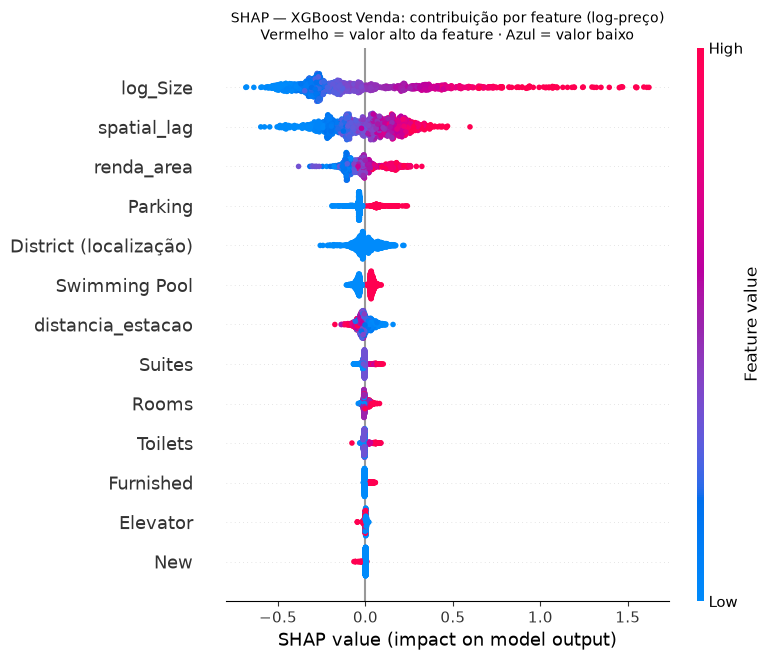

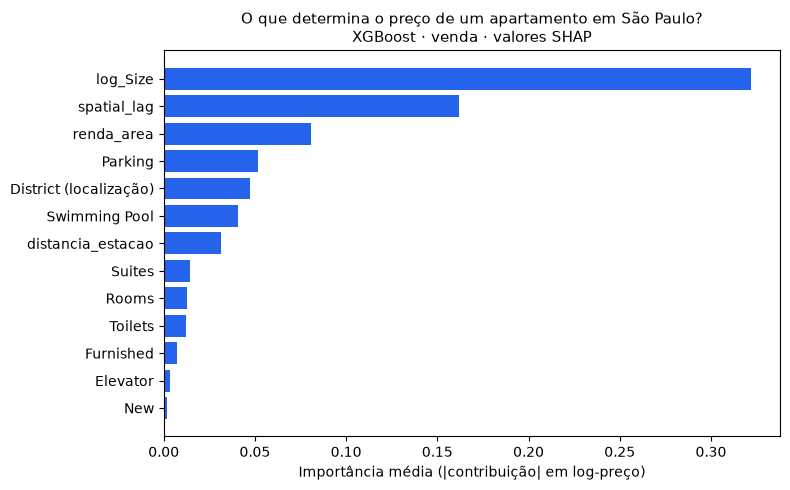

In [40]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Matriz de FEATURES agregada (para colorir o beeswarm), espelhando shap_agg
X_vals_outras = X_shap_v.iloc[:, idx_outras].values
# District: usa a soma das dummies como "valor" (sempre ~1, cor neutra) — o que importa
# é a posição X (contribuição), não a cor, já que District agregado não tem escala única
X_district_proxy = X_shap_v.iloc[:, idx_district].values.sum(axis=1, keepdims=True)
X_vals_agg = np.hstack([X_vals_outras, X_district_proxy])

# ===== BEESWARM (técnico) =====
shap.summary_plot(
    shap_agg, X_vals_agg,
    feature_names=nomes_agg,
    plot_type="dot",          # beeswarm
    show=False,
    max_display=13,           # mostra todas as 13 features agregadas
)
plt.title("SHAP — XGBoost Venda: contribuição por feature (log-preço)\n"
          "Vermelho = valor alto da feature · Azul = valor baixo", fontsize=10)
plt.tight_layout()
plt.savefig("outputs/shap_beeswarm_venda.png", dpi=150, bbox_inches="tight")
plt.show()

# ===== BAR PLOT (comunicação) =====
ordem = np.argsort(importancia)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([nomes_agg[i] for i in ordem][::-1],
        [importancia[i] for i in ordem][::-1],
        color="#2563eb")
ax.set_xlabel("Importância média (|contribuição| em log-preço)")
ax.set_title("O que determina o preço de um apartamento em São Paulo?\n"
             "XGBoost · venda · valores SHAP", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/shap_bar_venda.png", dpi=150, bbox_inches="tight")
plt.show()

#### Resultado — leitura de direção (beeswarm)

O beeswarm confirma a importância E revela a direção de cada feature:

- **log_Size** (dominante): apê grande (vermelho) → preço sobe, com a maior dispersão
  de impacto do modelo. Tamanho é o motor.
- **spatial_lag** (2º): vizinhos caros → preço sobe. Validação visual da frente
  espacial — o lag se comporta exatamente como a teoria prevê.
- **renda_area** (3º): bairro de renda alta → preço sobe. Coerente.
- **distancia_estacao** — **achado contra-intuitivo:** estar LONGE da estação tende a
  SUBIR o preço. Não é causal — em SP, os bairros mais nobres (Jardins, Alto de
  Pinheiros, Morumbi) são orientados ao carro e distantes do metrô, enquanto a
  proximidade de estação correlaciona com bairros mais adensados e populares. A
  distância vira proxy invertida de status. É um efeito não-linear/dependente de
  bairro que a regressão linear não captou (por isso a distância foi inútil nela) mas
  a árvore extraiu — ilustração direta do trade-off interpretabilidade × captura de
  não-linearidade.
- **Parking, Swimming Pool**: amenidades premium, sobem o preço (modesto).
- **District (localização)**: efeito pequeno — lag e renda já capturaram a maior parte
  do sinal de localização (a cor é neutra por artefato da agregação; o que importa é a
  posição próxima de zero).
- **Suites, Rooms, Toilets**: comprimidas perto de zero — absorvidas pela correlação
  com o tamanho.

> **Síntese da interpretabilidade:** o SHAP recupera o "porquê" que o boosting custou.
> Tamanho + localização fina (lag) + entorno (renda) dirigem o preço; o achado da
> distância invertida mostra por que o ML supera a regressão (captura efeitos que a
> linearidade não expressa). A recomendação da app pode ser explicada feature a
> feature — honrando a exigência de interpretabilidade da tradição NBR.

### 9.3 — SHAP no campeão de aluguel (XGBoost): o mesmo padrão se repete?

Replica a análise no modelo de aluguel. Pergunta-chave para H3: as features dirigem o
preço de forma diferente entre comprar e alugar? Em especial — a distância à estação
inverte também no aluguel, ou o mercado de locação tem outra lógica espacial?

In [41]:
import joblib
modelo_a = joblib.load("models/modelo_campeao_aluguel.joblib")
print("nº features:", modelo_a.n_features_in_)
print("últimas 4:", [str(c) for c in modelo_a.feature_names_in_[-4:]])
print("tem as 3 espaciais?",
      all(f in [str(c) for c in modelo_a.feature_names_in_]
          for f in ["spatial_lag", "distancia_estacao", "renda_area"]))

nº features: 105
últimas 4: ['District_Água Rasa/São Paulo', 'spatial_lag', 'distancia_estacao', 'renda_area']
tem as 3 espaciais? True


Matriz SHAP aluguel: (1338, 105) | ordem confere: True

=== Importância SHAP (aluguel) — média |contribuição| em log-preço ===
  log_Size                     | 0.2432
  spatial_lag                  | 0.1662
  renda_area                   | 0.0765
  District (localização)       | 0.0647
  Parking                      | 0.0590
  Swimming Pool                | 0.0501
  Furnished                    | 0.0455
  distancia_estacao            | 0.0435
  Suites                       | 0.0407
  Toilets                      | 0.0196
  Rooms                        | 0.0117
  Elevator                     | 0.0033
  New                          | 0.0000


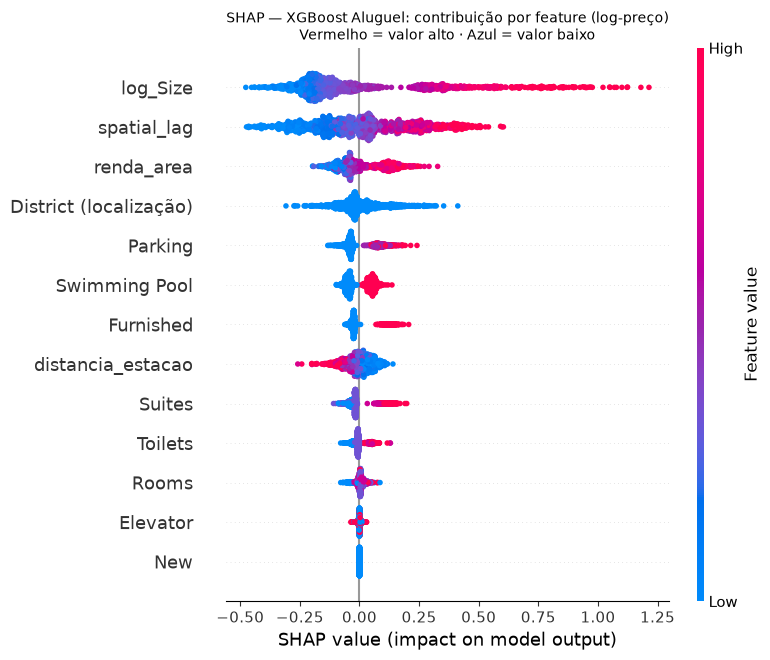

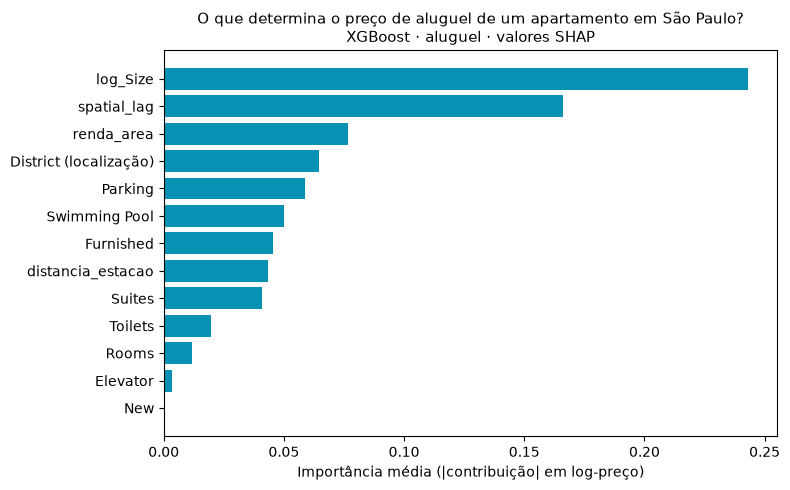

In [42]:
# Monta a matriz de teste de aluguel (105 features, na ordem do modelo)
X_shap_a = montar_matriz_arvore(df_aluguel, X_train_a, X_test_a, y_train_a_log, 3)
X_shap_a = X_shap_a[list(modelo_a.feature_names_in_)]
print("Matriz SHAP aluguel:", X_shap_a.shape,
      "| ordem confere:", list(X_shap_a.columns) == list(modelo_a.feature_names_in_))

# TreeExplainer
explainer_a = shap.TreeExplainer(modelo_a)
shap_values_a = explainer_a.shap_values(X_shap_a)

# Agrega District (agora 93 dummies)
cols_a = [str(c) for c in modelo_a.feature_names_in_]
idx_district_a = [i for i, c in enumerate(cols_a) if c.startswith("District_")]
idx_outras_a   = [i for i, c in enumerate(cols_a) if not c.startswith("District_")]
nomes_outras_a = [cols_a[i] for i in idx_outras_a]

shap_district_a = shap_values_a[:, idx_district_a].sum(axis=1, keepdims=True)
shap_agg_a = np.hstack([shap_values_a[:, idx_outras_a], shap_district_a])
nomes_agg_a = nomes_outras_a + ["District (localização)"]

importancia_a = np.abs(shap_agg_a).mean(axis=0)
ordem_a = np.argsort(importancia_a)[::-1]

print("\n=== Importância SHAP (aluguel) — média |contribuição| em log-preço ===")
for i in ordem_a:
    print(f"  {nomes_agg_a[i]:28} | {importancia_a[i]:.4f}")

# Beeswarm
X_vals_outras_a = X_shap_a.iloc[:, idx_outras_a].values
X_district_proxy_a = X_shap_a.iloc[:, idx_district_a].values.sum(axis=1, keepdims=True)
X_vals_agg_a = np.hstack([X_vals_outras_a, X_district_proxy_a])

shap.summary_plot(shap_agg_a, X_vals_agg_a, feature_names=nomes_agg_a,
                  plot_type="dot", show=False, max_display=13)
plt.title("SHAP — XGBoost Aluguel: contribuição por feature (log-preço)\n"
          "Vermelho = valor alto · Azul = valor baixo", fontsize=10)
plt.tight_layout()
plt.savefig("outputs/shap_beeswarm_aluguel.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar plot aluguel (comunicação / README / LinkedIn)
ordem_a = np.argsort(importancia_a)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([nomes_agg_a[i] for i in ordem_a][::-1],
        [importancia_a[i] for i in ordem_a][::-1],
        color="#0891b2")   # ciano, para distinguir do azul da venda
ax.set_xlabel("Importância média (|contribuição| em log-preço)")
ax.set_title("O que determina o preço de aluguel de um apartamento em São Paulo?\n"
             "XGBoost · aluguel · valores SHAP", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/shap_bar_aluguel.png", dpi=150, bbox_inches="tight")
plt.show()

#### Resultado — SHAP aluguel e comparação com venda (H3)

Ranking de importância (aluguel) e contraste com venda:

| Feature | Venda | Aluguel | Leitura |
|---------|-------|---------|---------|
| log_Size | 0,322 | 0,243 | domina menos no aluguel (hierarquia mais achatada) |
| spatial_lag | 0,162 | 0,166 | igual — localização fina é universal |
| renda_area | 0,081 | 0,077 | igual — entorno socioeconômico importa nos dois |
| Furnished | 0,007 | 0,046 | **salta no aluguel** — mobília é feature de locação, não de venda |
| distancia_estacao | 0,032 | 0,044 | **inverte de direção** (ver abaixo) |

**Achados de H3 — venda e aluguel diferem em O QUE dirige o preço, não só no nível:**

1. **Distância à estação inverte de sinal.** Na venda, longe da estação → preço SOBE
   (bairros nobres de SP são orientados ao carro). No aluguel, longe → preço CAI: o
   locatário depende mais de transporte público e paga por proximidade de metrô. A
   mesma feature, direção oposta — a evidência mais limpa de que os dois mercados têm
   lógicas espaciais distintas.
2. **Furnished só importa no aluguel** (0,046 vs 0,007). Locação mobiliada é um produto
   próprio (temporada, executivos); na venda, a mobília é irrelevante.
3. **Tamanho domina menos no aluguel** — hierarquia mais distribuída, coerente com o
   mercado de locação mais ruidoso (R² menor).
4. **Renda e spatial_lag pesam igual nos dois** — localização e entorno socioeconômico
   são determinantes universais de preço, independentes do tipo de negociação.

> **Síntese H3:** a decisão de modelar venda e aluguel separadamente (não como um modelo
> único com `Negotiation Type` como feature) está empiricamente justificada — os preços
> implícitos dos atributos são estruturalmente diferentes. A inversão de sinal da
> distância é o caso mais forte: um modelo único teria mediado os dois efeitos opostos e
> perdido ambos.

### 9.4 — Síntese: interpretabilidade nos dois paradigmas

O projeto investiga o trade-off interpretabilidade × acurácia, e a Fase 5 o resolve nos
dois lados:

- **Modelo preciso (XGBoost, campeão):** caixa-preta por natureza. Aberto via **SHAP**
  (9.2), que revela tamanho, localização fina (spatial_lag) e entorno (renda) como
  motores do preço — e os achados de H3 (distância invertida entre mercados, Furnished
  como feature de aluguel). Interpretabilidade recuperada *a posteriori*.
- **Modelo interpretável (regressão linear):** coeficientes seriam preços implícitos
  diretos — mas seus pressupostos são violados (6.1: não-normalidade, heterocedasticidade,
  multicolinearidade moderada em atributos de tamanho). A interpretação de coeficientes
  individuais é, portanto, **inviável com rigor** — e seria redundante com o SHAP, que
  entrega o mesmo insight sem depender de pressupostos distribucionais.

> **Conclusão do trade-off:** o ML compra acurácia (~1,8 p.p. de MAPE) ao custo da
> interpretabilidade nativa, mas o SHAP a devolve. A regressão oferece interpretabilidade
> nativa que, neste caso, os dados não sustentam estatisticamente. Para um AVM-produto,
> a combinação **XGBoost + SHAP** entrega o melhor dos dois: precisão e explicabilidade —
> esta última honrando a exigência interpretativa da tradição NBR, por outro caminho.